In [2]:
# ========================
# STD LIBS (Python nativo)
# ========================
import json
import time
import random
import subprocess
from pathlib import Path
from io import StringIO

# ==========================
# TERCEIROS (dados & web)
# ==========================
import pandas as pd
import numpy as np
import requests
from bs4 import BeautifulSoup

# ==========================
# SELENIUM (automação web)
# ==========================
from selenium import webdriver
from selenium.webdriver.common.by import By
from selenium.webdriver.support.ui import WebDriverWait
from selenium.webdriver.support import expected_conditions as EC
from selenium.common.exceptions import NoSuchElementException

# Opções para Firefox
from selenium.webdriver.firefox.options import Options


# ==========================
# VISUALIZAÇÃO (gráficos)
# ==========================
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objs as go
from plotly.offline import init_notebook_mode, iplot

# ==========================
# JUPYTER MAGIC (Notebook)
# ==========================
%matplotlib inline


In [5]:
#! Estatisticas gerais

import time
import random
from io import StringIO
import pandas as pd
from selenium import webdriver
from selenium.webdriver.firefox.options import Options
from selenium.webdriver.common.by import By
from selenium.webdriver.support.ui import WebDriverWait
from selenium.webdriver.support import expected_conditions as EC

agentes = [
    "Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/124.0.0.0 Safari/537.36",
    "Mozilla/5.0 (Macintosh; Intel Mac OS X 10_13_6) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/83.0.4103.61 Safari/537.36",
]
agente = random.choice(agentes)

options = Options()
options.set_preference("general.useragent.override", agente)
options.set_preference("dom.webdriver.enabled", False)
options.set_preference("media.peerconnection.enabled", False)
options.set_preference("privacy.trackingprotection.enabled", True)

driver = webdriver.Firefox(options=options)

try:
    api_url = "https://fbref.com/en/comps/24/stats/Serie-A-Stats#all_stats_standard"
    print(f"[1/1] Acessando: {api_url}")
    driver.get(api_url)

    # AUMENTAMOS PARA 60 SEGUNDOS
    # Se aparecer o captcha do Cloudflare, você tem 1 minuto para clicar
    print("[INFO] Aguardando a tabela... Se aparecer o Cloudflare, clique na caixa.")
    WebDriverWait(driver, 60).until(
        EC.presence_of_element_located((By.CSS_SELECTOR, "table"))
    )

    # Espera mais 2 segundinhos só pra garantir que a tabela carregou visualmente após o clique
    time.sleep(2)

    html = driver.page_source  
    tabelas = pd.read_html(StringIO(html))  

    tabela_brasileirao = tabelas[11]
    print(tabela_brasileirao.head())

    tabela_brasileirao.to_csv(r'G:\pythonProject\Aula_Cbf\data\standard_stats.csv', index=False)
    print("Tabela extraída com sucesso!")
    
    # Se tudo deu certo, ele fecha o navegador sozinho
    driver.quit()

except Exception as e:
    print(f"[ERRO] Falha no fluxo: {e}")
    print("[AVISO] O navegador não será fechado para você poder inspecionar.")
    # Removido o driver.quit() daqui para você poder ver a tela se der erro

finally:
    print("[INFO] Fim do processo. Pausa de segurança de 5 segundos...")
    time.sleep(5)


[1/1] Acessando: https://fbref.com/en/comps/24/stats/Serie-A-Stats#all_stats_standard
[INFO] Aguardando a tabela... Se aparecer o Cloudflare, clique na caixa.
[ERRO] Falha no fluxo: Message: WebDriver session does not exist, or is not active; For documentation on this error, please visit: https://www.selenium.dev/documentation/webdriver/troubleshooting/errors#invalidsessionidexception
Stacktrace:
RemoteError@chrome://remote/content/shared/RemoteError.sys.mjs:8:8
WebDriverError@chrome://remote/content/shared/webdriver/Errors.sys.mjs:202:5
InvalidSessionIDError@chrome://remote/content/shared/webdriver/Errors.sys.mjs:472:5
assert.that/<@chrome://remote/content/shared/webdriver/Assert.sys.mjs:581:13
assert.session@chrome://remote/content/shared/webdriver/Assert.sys.mjs:38:4
dispatch@chrome://remote/content/marionette/server.sys.mjs:315:19
execute@chrome://remote/content/marionette/server.sys.mjs:289:16
onPacket/<@chrome://remote/content/marionette/server.sys.mjs:262:20
onPacket@chrome://re

In [3]:
#! Estatisticas goleiros

# ========== 1) Iniciar o Tor ==========
try:
    # ajuste o caminho se necessário
    tor_path = r"C:\Tor\Browser\TorBrowser\Tor\tor.exe"
    subprocess.Popen([tor_path])
    print("[INFO] Tor iniciado com sucesso.")
except Exception as e:
    print(f"[ERRO] Falha ao iniciar o Tor: {e}")

# dá um tempo pro Tor subir
time.sleep(10)

# ========== 2) Configurar Firefox via Tor ==========
agentes = [
    "Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/124.0.0.0 Safari/537.36",
    "Mozilla/5.0 (Macintosh; Intel Mac OS X 10_13_6) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/83.0.4103.61 Safari/537.36",
    "Mozilla/5.0 (X11; Linux x86_64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/86.0.4240.75 Safari/537.36",
]
agente = random.choice(agentes)

options = Options()
# Proxy SOCKS5 do Tor
options.set_preference("network.proxy.type", 1)
options.set_preference("network.proxy.socks", "127.0.0.1")
options.set_preference("network.proxy.socks_port", 9050)
options.set_preference("network.proxy.socks_remote_dns", True)

# User-Agent custom
options.set_preference("general.useragent.override", agente)


options.set_preference("dom.webdriver.enabled", False)
options.set_preference("media.peerconnection.enabled", False)  # desabilita WebRTC
options.set_preference("privacy.trackingprotection.enabled", True)

# Headless se quiser (opcional):
# options.add_argument("-headless")

# Se o geckodriver não estiver no PATH, baixe e coloque o .exe no PATH, ou use webdriver-manager
driver = webdriver.Firefox(options=options)

# ========== 3) Abrir e reaproveitar HTML renderizado ==========
try:
    # (opcional) testar o IP via Tor
    driver.get("https://check.torproject.org/")
    WebDriverWait(driver, 20).until(EC.presence_of_element_located((By.TAG_NAME, "body")))
    print("[INFO] Página de verificação do Tor carregada.")

    api_url = "https://fbref.com/en/comps/24/keepers/Serie-A-Stats"
    print(f"[1/1] Acessando: {api_url}")
    driver.get(api_url)

    # aguarda aparecer pelo menos 1 tabela
    WebDriverWait(driver, 25).until(
        EC.presence_of_element_located((By.CSS_SELECTOR, "table"))
    )

    html = driver.page_source  # HTML da aba atual aberta via Selenium
    table = pd.read_html(StringIO(html))  # lê TODAS as tabelas encontradas

    # pegue ID conforme necessário
    goleiros_brasileirao = table[11]
    print(goleiros_brasileirao.head())

    # Exportar para CSV
    goleiros_brasileirao.to_csv(r'G:\pythonProject\Aula_Cbf\data\goalkepper_stats.csv', index=False)
    print("Tabela extraída com sucesso!")
    
except Exception as e:
    print(f"[ERRO] Falha no fluxo Selenium+Tor: {e}")
finally:
    driver.quit()  # feche quando terminar
    pass


[INFO] Tor iniciado com sucesso.
[INFO] Página de verificação do Tor carregada.
[1/1] Acessando: https://fbref.com/en/comps/24/keepers/Serie-A-Stats
  Unnamed: 0_level_0 Unnamed: 1_level_0 Unnamed: 2_level_0 Unnamed: 3_level_0  \
                  Rk             Player             Nation                Pos   
0                  1            Anthoni             br BRA                 GK   
1                  2         Léo Aragão             br BRA                 GK   
2                  3      Lucas Arcanjo             br BRA                 GK   
3                  4     Gabriel Brazão             br BRA                 GK   
4                  5             Brenno             br BRA                 GK   

  Unnamed: 4_level_0 Unnamed: 5_level_0 Unnamed: 6_level_0 Playing Time  \
               Squad                Age               Born           MP   
0      Internacional             23-271               2002           17   
1           Cruzeiro             23-185               2002

In [4]:
#! Estatisticas goleiros

# ========== 1) Iniciar o Tor ==========
try:
    # ajuste o caminho se necessário
    tor_path = r"C:\Tor\Browser\TorBrowser\Tor\tor.exe"
    subprocess.Popen([tor_path])
    print("[INFO] Tor iniciado com sucesso.")
except Exception as e:
    print(f"[ERRO] Falha ao iniciar o Tor: {e}")

# dá um tempo pro Tor subir
time.sleep(10)

# ========== 2) Configurar Firefox via Tor ==========
agentes = [
    "Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/124.0.0.0 Safari/537.36",
    "Mozilla/5.0 (Macintosh; Intel Mac OS X 10_13_6) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/83.0.4103.61 Safari/537.36",
    "Mozilla/5.0 (X11; Linux x86_64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/86.0.4240.75 Safari/537.36",
]
agente = random.choice(agentes)

options = Options()
# Proxy SOCKS5 do Tor
options.set_preference("network.proxy.type", 1)
options.set_preference("network.proxy.socks", "127.0.0.1")
options.set_preference("network.proxy.socks_port", 9050)
options.set_preference("network.proxy.socks_remote_dns", True)

# User-Agent custom
options.set_preference("general.useragent.override", agente)


options.set_preference("dom.webdriver.enabled", False)
options.set_preference("media.peerconnection.enabled", False)  # desabilita WebRTC
options.set_preference("privacy.trackingprotection.enabled", True)

# Headless se quiser (opcional):
# options.add_argument("-headless")

# Se o geckodriver não estiver no PATH, baixe e coloque o .exe no PATH, ou use webdriver-manager
driver = webdriver.Firefox(options=options)

# ========== 3) Abrir e reaproveitar HTML renderizado ==========
try:
    # (opcional) testar o IP via Tor
    driver.get("https://check.torproject.org/")
    WebDriverWait(driver, 20).until(EC.presence_of_element_located((By.TAG_NAME, "body")))
    print("[INFO] Página de verificação do Tor carregada.")

    api_url = "https://fbref.com/en/comps/24/defense/Serie-A-Stats"
    print(f"[1/1] Acessando: {api_url}")
    driver.get(api_url)

    # aguarda aparecer pelo menos 1 tabela
    WebDriverWait(driver, 25).until(
        EC.presence_of_element_located((By.CSS_SELECTOR, "table"))
    )

    html = driver.page_source  # HTML da aba atual aberta via Selenium
    table = pd.read_html(StringIO(html))  # lê TODAS as tabelas encontradas

    # pegue ID conforme necessário
    defensores_brasileirao = table[11]
    print(defensores_brasileirao.head())

    # Exportar para CSV
    defensores_brasileirao.to_csv(r'G:\pythonProject\Aula_Cbf\data\defensive_stats.csv', index=False)
    print("Tabela extraída com sucesso!")
    
except Exception as e:
    print(f"[ERRO] Falha no fluxo Selenium+Tor: {e}")
finally:
    driver.quit()  # feche quando terminar
    pass


[INFO] Tor iniciado com sucesso.
[INFO] Página de verificação do Tor carregada.
[1/1] Acessando: https://fbref.com/en/comps/24/defense/Serie-A-Stats
  Unnamed: 0_level_0 Unnamed: 1_level_0 Unnamed: 2_level_0 Unnamed: 3_level_0  \
                  Rk             Player             Nation                Pos   
0                  1              Abner             br BRA                 DF   
1                  2    Nicolás Acevedo             uy URU                 MF   
2                  3     Luciano Acosta             ar ARG              MF,FW   
3                  4              Adson             br BRA              FW,MF   
4                  5     Braian Aguirre             ar ARG                 DF   

  Unnamed: 4_level_0 Unnamed: 5_level_0 Unnamed: 6_level_0 Unnamed: 7_level_0  \
               Squad                Age               Born                90s   
0          Juventude             21-185               2004               14.2   
1              Bahia             26-190 

In [5]:
#! Estatisticas goleiros

# ========== 1) Iniciar o Tor ==========
try:
    # ajuste o caminho se necessário
    tor_path = r"C:\Tor\Browser\TorBrowser\Tor\tor.exe"
    subprocess.Popen([tor_path])
    print("[INFO] Tor iniciado com sucesso.")
except Exception as e:
    print(f"[ERRO] Falha ao iniciar o Tor: {e}")

# dá um tempo pro Tor subir
time.sleep(10)

# ========== 2) Configurar Firefox via Tor ==========
agentes = [
    "Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/124.0.0.0 Safari/537.36",
    "Mozilla/5.0 (Macintosh; Intel Mac OS X 10_13_6) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/83.0.4103.61 Safari/537.36",
    "Mozilla/5.0 (X11; Linux x86_64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/86.0.4240.75 Safari/537.36",
]
agente = random.choice(agentes)

options = Options()
# Proxy SOCKS5 do Tor
options.set_preference("network.proxy.type", 1)
options.set_preference("network.proxy.socks", "127.0.0.1")
options.set_preference("network.proxy.socks_port", 9050)
options.set_preference("network.proxy.socks_remote_dns", True)

# User-Agent custom
options.set_preference("general.useragent.override", agente)


options.set_preference("dom.webdriver.enabled", False)
options.set_preference("media.peerconnection.enabled", False)  # desabilita WebRTC
options.set_preference("privacy.trackingprotection.enabled", True)

# Headless se quiser (opcional):
# options.add_argument("-headless")

# Se o geckodriver não estiver no PATH, baixe e coloque o .exe no PATH, ou use webdriver-manager
driver = webdriver.Firefox(options=options)

# ========== 3) Abrir e reaproveitar HTML renderizado ==========
try:
    # (opcional) testar o IP via Tor
    driver.get("https://check.torproject.org/")
    WebDriverWait(driver, 20).until(EC.presence_of_element_located((By.TAG_NAME, "body")))
    print("[INFO] Página de verificação do Tor carregada.")

    api_url = "https://fbref.com/en/comps/24/passing/Serie-A-Stats"
    print(f"[1/1] Acessando: {api_url}")
    driver.get(api_url)

    # aguarda aparecer pelo menos 1 tabela
    WebDriverWait(driver, 25).until(
        EC.presence_of_element_located((By.CSS_SELECTOR, "table"))
    )

    html = driver.page_source  # HTML da aba atual aberta via Selenium
    table = pd.read_html(StringIO(html))  # lê TODAS as tabelas encontradas

    # pegue ID conforme necessário
    passes_brasileirao = table[11]
    print(passes_brasileirao.head())

    # Exportar para CSV
    passes_brasileirao.to_csv(r'G:\pythonProject\Aula_Cbf\data\passing_stats.csv', index=False)
    print("Tabela extraída com sucesso!")
    
except Exception as e:
    print(f"[ERRO] Falha no fluxo Selenium+Tor: {e}")
finally:
    driver.quit()  # feche quando terminar
    pass


[INFO] Tor iniciado com sucesso.
[INFO] Página de verificação do Tor carregada.
[1/1] Acessando: https://fbref.com/en/comps/24/passing/Serie-A-Stats
  Unnamed: 0_level_0 Unnamed: 1_level_0 Unnamed: 2_level_0 Unnamed: 3_level_0  \
                  Rk             Player             Nation                Pos   
0                  1              Abner             br BRA                 DF   
1                  2    Nicolás Acevedo             uy URU                 MF   
2                  3     Luciano Acosta             ar ARG              MF,FW   
3                  4              Adson             br BRA              FW,MF   
4                  5     Braian Aguirre             ar ARG                 DF   

  Unnamed: 4_level_0 Unnamed: 5_level_0 Unnamed: 6_level_0 Unnamed: 7_level_0  \
               Squad                Age               Born                90s   
0          Juventude             21-185               2004               14.2   
1              Bahia             26-190 

In [ ]:
import pandas as pd
import time
import random
import subprocess
from io import StringIO
from selenium import webdriver
from selenium.webdriver.firefox.options import Options
from selenium.webdriver.common.by import By
from selenium.webdriver.support.ui import WebDriverWait
from selenium.webdriver.support import expected_conditions as EC

def extrai_tabela_web_tor(url_pagina: str, caminho_csv: str) -> pd.DataFrame:
    """
    Função para extrair uma tabela de uma URL usando Selenium com proxy Tor.

    Args:
        url_pagina (str): A URL da página web a ser acessada.
        caminho_csv (str): O caminho completo onde o DataFrame será salvo (.csv).

    Returns:
        pd.DataFrame: O DataFrame extraído da página.
    """
    
    # --- 1) Configurações Fixas ---
    
    # Ajuste o caminho do Tor se necessário
    tor_path = r"C:\Tor\Browser\TorBrowser\Tor\tor.exe" 

    # Lista de User-Agents
    agentes = [
        "Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/124.0.0.0 Safari/537.36",
        "Mozilla/5.0 (Macintosh; Intel Mac OS X 10_13_6) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/83.0.4103.61 Safari/537.36",
        "Mozilla/5.0 (X11; Linux x86_64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/86.0.4240.75 Safari/537.36",
    ]
    agente = random.choice(agentes)

    # --- 2) Iniciar o Tor (fora do try/finally do driver) ---
    try:
        subprocess.Popen([tor_path])
        print("[INFO] Tor iniciado com sucesso.")
        time.sleep(10) # Tempo para o Tor estabilizar
    except Exception as e:
        print(f"[ERRO] Falha ao iniciar o Tor. Prosseguindo sem ele (pode falhar o scraping): {e}")

    driver = None # Inicializa a variável fora do bloco try
    try:
        # --- 3) Configurar Firefox via Tor ---
        options = Options()
        # Proxy SOCKS5 do Tor
        options.set_preference("network.proxy.type", 1)
        options.set_preference("network.proxy.socks", "127.0.0.1")
        options.set_preference("network.proxy.socks_port", 9050)
        options.set_preference("network.proxy.socks_remote_dns", True)

        # User-Agent custom e outras configurações
        options.set_preference("general.useragent.override", agente)
        options.set_preference("dom.webdriver.enabled", False)
        options.set_preference("media.peerconnection.enabled", False)
        options.set_preference("privacy.trackingprotection.enabled", True)
        # options.add_argument("-headless") # Opção de headless

        driver = webdriver.Firefox(options=options)
        
        # Testar o IP via Tor (opcional, como no seu código original)
        driver.get("https://check.torproject.org/")
        WebDriverWait(driver, 20).until(EC.presence_of_element_located((By.TAG_NAME, "body")))
        print("[INFO] Página de verificação do Tor carregada.")

        # --- 4) Acessar a URL do Parâmetro e Extrair ---
        print(f"[1/1] Acessando: {url_pagina}")
        driver.get(url_pagina)

        # Aguarda aparecer pelo menos 1 tabela
        WebDriverWait(driver, 25).until(
            EC.presence_of_element_located((By.CSS_SELECTOR, "table"))
        )

        html = driver.page_source  
        tabelas = pd.read_html(StringIO(html))  

        # **ATENÇÃO:** Mantenha a lógica de indexação da tabela correta.
        # No seu código original, era o índice [11].
        df_extraido = tabelas[11]
        print(f"Tabela extraída com {len(df_extraido)} linhas. Head:\n{df_extraido.head()}")

        # --- 5) Exportar para CSV (usando o caminho do parâmetro) ---
        df_extraido.to_csv(caminho_csv, index=False)
        print(f"Dados salvos com sucesso em: {caminho_csv}")
        
        return df_extraido # Retorna o DataFrame

    except Exception as e:
        print(f"[ERRO] Falha no fluxo Selenium+Tor para {url_pagina}: {e}")
        return pd.DataFrame() # Retorna um DataFrame vazio em caso de erro
    finally:
        if driver:
             driver.quit() # Garante que o driver feche

# ====================================================================
# EXEMPLO DE USO DA FUNÇÃO:
# ====================================================================

# 1. Definir os novos parâmetros
URL = "https://fbref.com/en/comps/24/passing/Serie-A-Stats"
CAMINHO_ARQUIVO = r'G:\pythonProject\Aula_Cbf\data\passing_stats_2025.csv'

# 2. Chamar a função
df_pass = extrai_tabela_web_tor(
    url_pagina=URL, 
    caminho_csv=CAMINHO_ARQUIVO
)

if not df_pass.empty:
    print("\n[SUCESSO] O DataFrame está disponível para processamento adicional.")

In [6]:
import pandas as pd

def clean_fbref_cols(df: pd.DataFrame) -> pd.DataFrame:
    """
    - Se colunas forem MultiIndex (FBRef), usa o 2º nível (nomes reais).
    - Para colunas cujo 1º nível == 'Per 90 Minutes', adiciona sufixo '_90'.
    - Mantém 'Performance' sem mudanças.
    """
    if not isinstance(df.columns, pd.MultiIndex):
        return df  # nada a fazer

    new_cols = []
    for col in df.columns:
        # col é uma tupla (nivel0, nivel1)
        g = str(col[0]).strip() if len(col) > 1 else ""
        name = str(col[1]).strip() if len(col) > 1 else str(col[0]).strip()

        # Alguns vêm como 'Unnamed: 0_level_0' etc. -> ignora
        if g.lower().startswith("unnamed"):
            g = ""

        # Regra: apenas Per 90 Minutes ganha _90
        if g == "Per 90 Minutes":
            name = f"{name}_90"

        new_cols.append(name)

    df = df.copy()
    df.columns = new_cols
    return df


In [7]:
#limpando as colunas 
tabela_brasileirao      = clean_fbref_cols(tabela_brasileirao)
goleiros_brasileirao    = clean_fbref_cols(goleiros_brasileirao)
defensores_brasileirao  = clean_fbref_cols(defensores_brasileirao)
passes_brasileirao      = clean_fbref_cols(passes_brasileirao)

In [9]:
#salvando tabela cabeçalho limpo
tabela_brasileirao.to_csv(r'G:\pythonProject\Aula_Cbf\data\processed\standard_stats.csv', index=False)
goleiros_brasileirao.to_csv(r'G:\pythonProject\Aula_Cbf\data\processed\goalkepper_stats.csv', index=False)
defensores_brasileirao.to_csv(r'G:\pythonProject\Aula_Cbf\data\processed\defensive_stats.csv', index=False)
passes_brasileirao.to_csv(r'G:\pythonProject\Aula_Cbf\data\processed\passing_stats.csv', index=False)

In [1]:
import pandas as pd

# Carregar os arquivos
df_std = pd.read_csv(r'G:\pythonProject\Aula_Cbf\data\processed\standard_stats.csv')
df_pass = pd.read_csv(r'G:\pythonProject\Aula_Cbf\data\processed\passing_stats.csv')
df_def = pd.read_csv(r'G:\pythonProject\Aula_Cbf\data\processed\defensive_stats.csv')
df_gk = pd.read_csv(r'G:\pythonProject\Aula_Cbf\data\processed\goalkepper_stats.csv')


# Lista de colunas comuns (chave de junção + metadados do jogador)
common_cols = ['Player', 'Nation', 'Pos', 'Squad', 'Age', 'Born']

# Função para remover colunas duplicadas (exceto as comuns)
def merge_without_duplicates(df1, df2, on_cols):
    # Colunas a serem adicionadas (não estão em df1 ou não são comuns)
    cols_to_add = [col for col in df2.columns if col not in df1.columns or col in on_cols]
    df2_unique = df2[cols_to_add]
    return pd.merge(df1, df2_unique, on=on_cols, how='outer')

# Começar com o standard
df_combined = df_std.copy()

# Mesclar com passing
df_combined = merge_without_duplicates(df_combined, df_pass, common_cols)

# Mesclar com defensive
df_combined = merge_without_duplicates(df_combined, df_def, common_cols)

# Mesclar com goalkeepers
df_combined = merge_without_duplicates(df_combined, df_gk, common_cols)

# Opcional: Reordenar colunas (metadados primeiro)
meta_cols = common_cols + ['MP', 'Starts', 'Min', '90s']
other_cols = [col for col in df_combined.columns if col not in meta_cols]
df_combined = df_combined[meta_cols + other_cols]

# Salvar o resultado (opcional)
df_combined.to_csv(r'G:\pythonProject\Aula_Cbf\data\processed\combined_player_stats.csv', index=False)

In [2]:
df_combined.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25114 entries, 0 to 25113
Data columns (total 86 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   Player       25114 non-null  object
 1   Nation       25114 non-null  object
 2   Pos          25114 non-null  object
 3   Squad        25114 non-null  object
 4   Age          25114 non-null  object
 5   Born         25114 non-null  object
 6   MP           25114 non-null  object
 7   Starts       25114 non-null  object
 8   Min          25114 non-null  object
 9   90s          25114 non-null  object
 10  Rk           25114 non-null  object
 11  Gls          25114 non-null  object
 12  Ast          25114 non-null  object
 13  G+A          25114 non-null  object
 14  G-PK         25114 non-null  object
 15  PK           25114 non-null  object
 16  PKatt        25114 non-null  object
 17  CrdY         25114 non-null  object
 18  CrdR         25114 non-null  object
 19  xG           25114 non-nu

In [3]:
serie_a = df_combined.copy()
serie_a.head(4)

,Player,Nation,Pos,Squad,Age,Born,MP,Starts,Min,90s,...,Save%,W,D,L,CS,CS%,PKA,PKsv,PKm,Save%.1
0,Abner,br BRA,DF,Juventude,21-185,2004,18,13,1281,14.2,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Adam Bareiro,py PAR,FW,Fortaleza,29-087,1996,12,1,256,2.8,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Ademir Santos,br BRA,FW,Bahia,30-247,1995,21,17,1268,14.1,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,Aderlan Silva,br BRA,DF,Santos,35-064,1990,2,1,87,1.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [4]:
serie_a.tail(4)

,Player,Nation,Pos,Squad,Age,Born,MP,Starts,Min,90s,...,Save%,W,D,L,CS,CS%,PKA,PKsv,PKm,Save%.1
25110,Ángel Romero,py PAR,"FW,MF",Corinthians,33-109,1992,23,10,962,10.7,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
25111,Éverson,br BRA,GK,Atlético Mineiro,35-091,1990,26,26,2340,26.0,...,73.5,8,8,10,8,30.8,3,0,0,0.0
25112,Ênio,br BRA,"MF,FW",Juventude,24-232,2001,20,8,969,10.8,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
25113,Óscar Romero,py PAR,"MF,FW",Internacional,33-109,1992,14,5,482,5.4,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [5]:
# Excluir a coluna "Matches"
serie_a.drop(columns=["Matches"], inplace=True, errors="ignore")

# Exibir as primeiras linhas para confirmar as alterações
display(serie_a.head())

,Player,Nation,Pos,Squad,Age,Born,MP,Starts,Min,90s,...,Save%,W,D,L,CS,CS%,PKA,PKsv,PKm,Save%.1
0,Abner,br BRA,DF,Juventude,21-185,2004,18,13,1281,14.2,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Adam Bareiro,py PAR,FW,Fortaleza,29-087,1996,12,1,256,2.8,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Ademir Santos,br BRA,FW,Bahia,30-247,1995,21,17,1268,14.1,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,Aderlan Silva,br BRA,DF,Santos,35-064,1990,2,1,87,1.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,Aderlan Silva,br BRA,DF,Sport Recife,35-064,1990,8,6,555,6.2,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [6]:
serie_a.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25114 entries, 0 to 25113
Data columns (total 85 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   Player       25114 non-null  object
 1   Nation       25114 non-null  object
 2   Pos          25114 non-null  object
 3   Squad        25114 non-null  object
 4   Age          25114 non-null  object
 5   Born         25114 non-null  object
 6   MP           25114 non-null  object
 7   Starts       25114 non-null  object
 8   Min          25114 non-null  object
 9   90s          25114 non-null  object
 10  Rk           25114 non-null  object
 11  Gls          25114 non-null  object
 12  Ast          25114 non-null  object
 13  G+A          25114 non-null  object
 14  G-PK         25114 non-null  object
 15  PK           25114 non-null  object
 16  PKatt        25114 non-null  object
 17  CrdY         25114 non-null  object
 18  CrdR         25114 non-null  object
 19  xG           25114 non-nu

In [7]:

def convert_fbref_dtypes(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()

    # ---- 1. Colunas categóricas (texto) ----
    text_cols = ["Player", "Nation", "Pos", "Squad"]

    # ---- 2. Coluna Rk -> int ----
    df["Rk"] = pd.to_numeric(df["Rk"], errors="coerce").astype("Int64")

    # ---- 3. Coluna Born -> ano (int) ----
    df["Born"] = pd.to_numeric(df["Born"], errors="coerce").astype("Int64")

    # ---- 4. Coluna Age -> anos + dias/365 ----
    def parse_age(age_str):
        try:
            years, days = age_str.split("-")
            val = int(years) + int(days) / 365
            return round(val, 2)   # arredonda para 2 casas decimais
        except:
            return pd.NA

    df["Age"] = df["Age"].astype(str).apply(parse_age).astype("Float64")

    # ---- 5. Todas as outras colunas (numéricas) ----
    num_cols = [c for c in df.columns if c not in text_cols + ["Rk", "Born", "Age"]]
    df[num_cols] = df[num_cols].apply(pd.to_numeric, errors="coerce").astype("Float64")

    return df


In [8]:
serie_a = convert_fbref_dtypes(serie_a)

In [9]:
serie_a

,Player,Nation,Pos,Squad,Age,Born,MP,Starts,Min,90s,...,Save%,W,D,L,CS,CS%,PKA,PKsv,PKm,Save%.1
0,Abner,br BRA,DF,Juventude,21.51,2004,18.0,13.0,1281.0,14.2,...,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>
1,Adam Bareiro,py PAR,FW,Fortaleza,29.24,1996,12.0,1.0,256.0,2.8,...,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>
2,Ademir Santos,br BRA,FW,Bahia,30.68,1995,21.0,17.0,1268.0,14.1,...,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>
3,Aderlan Silva,br BRA,DF,Santos,35.18,1990,2.0,1.0,87.0,1.0,...,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>
4,Aderlan Silva,br BRA,DF,Sport Recife,35.18,1990,8.0,6.0,555.0,6.2,...,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
25109,Álvaro Montoro,ar ARG,FW,Botafogo (RJ),18.51,2007,11.0,9.0,745.0,8.3,...,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>
25110,Ángel Romero,py PAR,"FW,MF",Corinthians,33.3,1992,23.0,10.0,962.0,10.7,...,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>
25111,Éverson,br BRA,GK,Atlético Mineiro,35.25,1990,26.0,26.0,2340.0,26.0,...,73.5,8.0,8.0,10.0,8.0,30.8,3.0,0.0,0.0,0.0
25112,Ênio,br BRA,"MF,FW",Juventude,24.64,2001,20.0,8.0,969.0,10.8,...,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>


In [10]:
display(serie_a.dtypes)

Player      object
Nation      object
Pos         object
Squad       object
Age        Float64
            ...   
CS%        Float64
PKA        Float64
PKsv       Float64
PKm        Float64
Save%.1    Float64
Length: 85, dtype: object

In [11]:
serie_a.isna().sum()

Player         0
Nation         0
Pos            0
Squad          0
Age        24389
           ...  
CS%        25068
PKA        25067
PKsv       25067
PKm        25067
Save%.1    25080
Length: 85, dtype: int64

In [12]:
# Mostra apenas as linhas com pelo menos 1 NaN
df_nulls = serie_a[serie_a.isna().any(axis=1)]
print(df_nulls.shape)   
df_nulls.head()


(25099, 85)


,Player,Nation,Pos,Squad,Age,Born,MP,Starts,Min,90s,...,Save%,W,D,L,CS,CS%,PKA,PKsv,PKm,Save%.1
0,Abner,br BRA,DF,Juventude,21.51,2004,18.0,13.0,1281.0,14.2,...,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>
1,Adam Bareiro,py PAR,FW,Fortaleza,29.24,1996,12.0,1.0,256.0,2.8,...,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>
2,Ademir Santos,br BRA,FW,Bahia,30.68,1995,21.0,17.0,1268.0,14.1,...,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>
3,Aderlan Silva,br BRA,DF,Santos,35.18,1990,2.0,1.0,87.0,1.0,...,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>
4,Aderlan Silva,br BRA,DF,Sport Recife,35.18,1990,8.0,6.0,555.0,6.2,...,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>


# Esses foram os cabecalhos de mudança de tabela, vamos excluir

In [21]:
# remove linhas onde Rk está vazio
serie_a = serie_a.dropna(subset=["Rk"]).reset_index(drop=True)


In [36]:
serie_a.Squad.unique()

array(['Juventude', 'Fortaleza', 'Bahia', 'Santos', 'Sport Recife',
       'Vasco da Gama', 'Fluminense', 'Palmeiras', 'Internacional',
       'Flamengo', 'RB Bragantino', 'Vitória', 'São Paulo',
       'Atlético Mineiro', 'Ceará', 'Mirassol', 'Corinthians', 'Grêmio',
       'Botafogo (RJ)', 'Cruzeiro', 'Squad'], dtype=object)

In [22]:
serie_a.isna().sum()

Rk             0
Player         0
Nation         0
Pos            0
Squad          0
Age            0
Born           0
MP             0
Starts         0
Min            0
90s            0
Gls            0
Ast            0
G+A            0
G-PK           0
PK             0
PKatt          0
CrdY           0
CrdR           0
xG             0
npxG           0
xAG            0
npxG+xAG       0
PrgC           0
PrgP           0
PrgR           0
Gls_90         0
Ast_90         0
G+A_90         0
G-PK_90        0
G+A-PK_90      0
xG_90          0
xAG_90         0
xG+xAG_90      0
npxG_90        0
npxG+xAG_90    0
dtype: int64

In [13]:
# Total de Gols - Excluindo Pênaltis
Total_Gols = serie_a['G-PK'].sum()
print(Total_Gols)

616.0


In [14]:
# Gols de Pênalti
Total_GolsPenalti = serie_a['PK'].sum()
print(Total_GolsPenalti)

67.0


In [15]:
# Tentativas de Pênalti
Total_TentativasPenalti = serie_a['PKatt'].sum()
print(Total_TentativasPenalti)

83.0


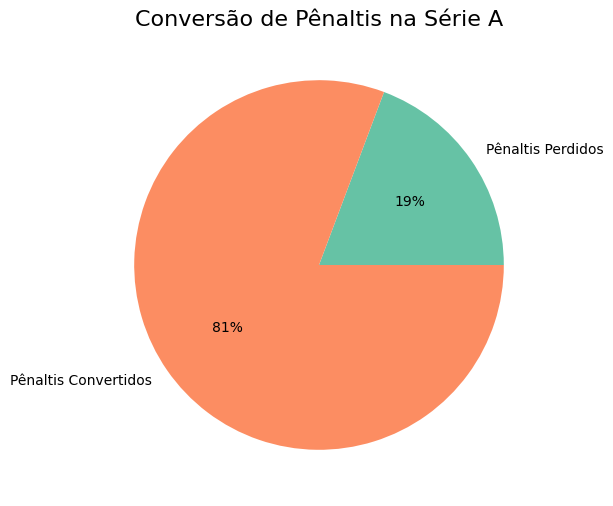

In [18]:
# Gráfico de pizza: pênaltis convertidos vs. desperdiçados
plt.figure(figsize=(13, 6))
plt_nao_convertidos = serie_a['PKatt'].sum() - Total_GolsPenalti  
dados = [plt_nao_convertidos, Total_GolsPenalti]
rotulos = ['Pênaltis Perdidos', 'Pênaltis Convertidos']
cores = sns.color_palette('Set2')

# Cria o gráfico de pizza
plt.pie(dados, labels=rotulos, colors=cores, autopct='%.0f%%')

# Adiciona o título
plt.title('Conversão de Pênaltis na Série A', fontsize=16)

# Exibe o gráfico
plt.show()

In [19]:
# Posições únicas

serie_a['Pos'].unique()

array(['DF', 'FW', 'FW,MF', 'GK', 'MF,FW', 'DF,FW', 'MF', 'MF,DF',
       'FW,DF', 'DF,MF', 'Pos'], dtype=object)

In [20]:
# Total de jogadores FW (atacantes)

serie_a[serie_a['Pos'] == 'FW']

,Player,Nation,Pos,Squad,Age,Born,MP,Starts,Min,90s,...,Save%,W,D,L,CS,CS%,PKA,PKsv,PKm,Save%.1
1,Adam Bareiro,py PAR,FW,Fortaleza,29.24,1996,12.0,1.0,256.0,2.8,...,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>
2,Ademir Santos,br BRA,FW,Bahia,30.68,1995,21.0,17.0,1268.0,14.1,...,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>
20,Alejandro Martínez,ar ARG,FW,Ceará,28.52,1997,2.0,0.0,49.0,0.5,...,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>
21,Alesson,br BRA,FW,Mirassol,26.68,1999,17.0,9.0,897.0,10.0,...,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>
40,Andre Martins,br BRA,FW,Grêmio,23.84,2001,17.0,4.0,539.0,6.0,...,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
25072,Vitor Roque,br BRA,FW,Palmeiras,20.64,2005,26.0,19.0,1655.0,18.4,...,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>
25088,Willian,br BRA,FW,Grêmio,37.2,1988,3.0,3.0,151.0,1.7,...,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>
25091,Willian José,br BRA,FW,Bahia,33.91,1991,23.0,19.0,1325.0,14.7,...,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>
25102,Yuri Alberto,br BRA,FW,Corinthians,24.59,2001,19.0,14.0,1398.0,15.5,...,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>


In [21]:
# Jogadores de diferentes nacionalidades

np.size((serie_a['Nation'].unique()))

21

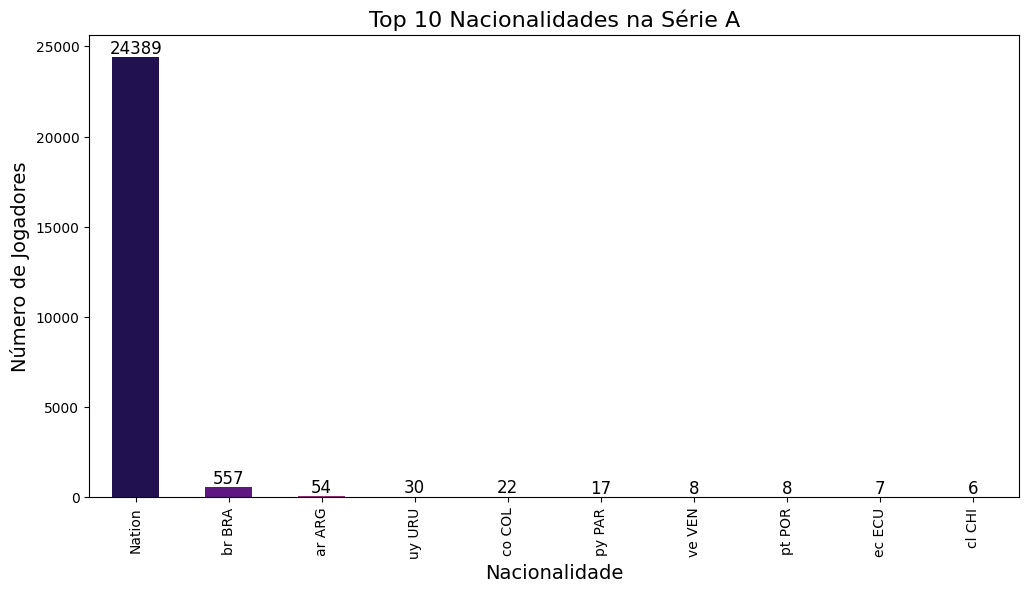

In [22]:
# Maior número de jogadores por país

# Agrupando e ordenando os dados
nacionalidade = serie_a.groupby('Nation').size().sort_values(ascending=False)

# Criando o gráfico de barras
ax = nacionalidade.head(10).plot(kind='bar', figsize=(12, 6), color=sns.color_palette("magma"))

# Adicionando os valores no topo das barras
for barra in ax.patches:
    ax.annotate(
        f'{int(barra.get_height())}',  # Valor a ser exibido
        (barra.get_x() + barra.get_width() / 2, barra.get_height()),  # Posição
        ha='center',  # Alinhamento horizontal
        va='bottom',  # Alinhamento vertical
        fontsize=12,  # Tamanho da fonte
        color='black'  # Cor da fonte
    )

# Adicionando título e rótulos dos eixos
ax.set_title('Top 10 Nacionalidades na Série A', fontsize=16)
ax.set_xlabel('Nacionalidade', fontsize=14)
ax.set_ylabel('Número de Jogadores', fontsize=14)

# Exibindo o gráfico
plt.show()

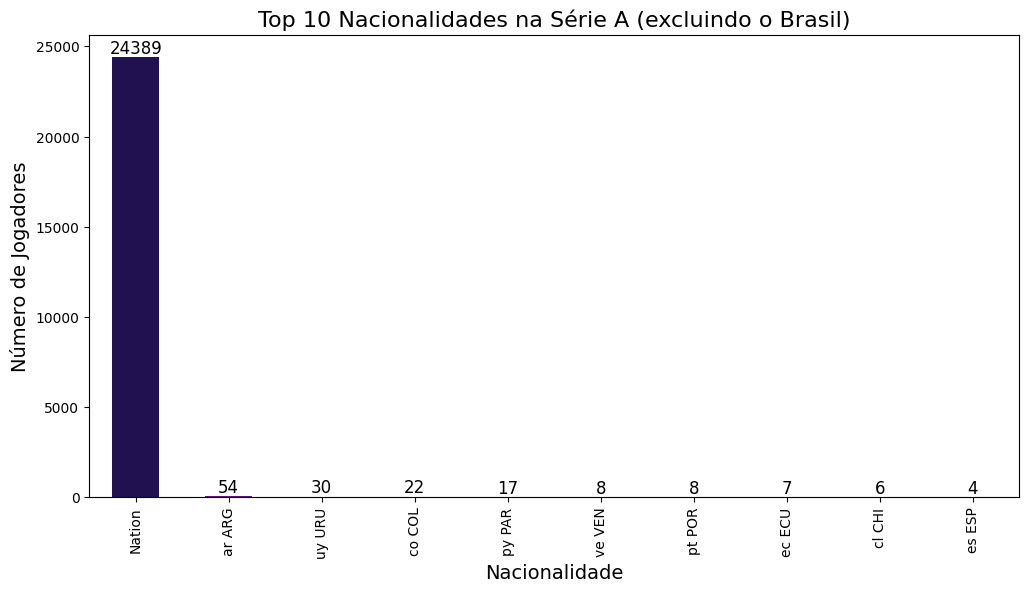

In [23]:
# Remover jogadores brasileiros (BRA)
serie_a_sem_brasileiros = serie_a[serie_a["Nation"] != "br BRA"]

# Agrupar e ordenar por nacionalidade
nacionalidade = serie_a_sem_brasileiros.groupby("Nation").size().sort_values(ascending=False)

# Plotar top 10
ax = nacionalidade.head(10).plot(
    kind="bar",
    figsize=(12, 6),
    color=sns.color_palette("magma")
)

# Adicionar valores em cima das barras
for barra in ax.patches:
    ax.annotate(
        f'{int(barra.get_height())}',
        (barra.get_x() + barra.get_width() / 2, barra.get_height()),
        ha="center",
        va="bottom",
        fontsize=12,
        color="black"
    )

# Títulos e rótulos dos eixos
ax.set_title("Top 10 Nacionalidades na Série A (excluindo o Brasil)", fontsize=16)
ax.set_xlabel("Nacionalidade", fontsize=14)
ax.set_ylabel("Número de Jogadores", fontsize=14)

plt.show()

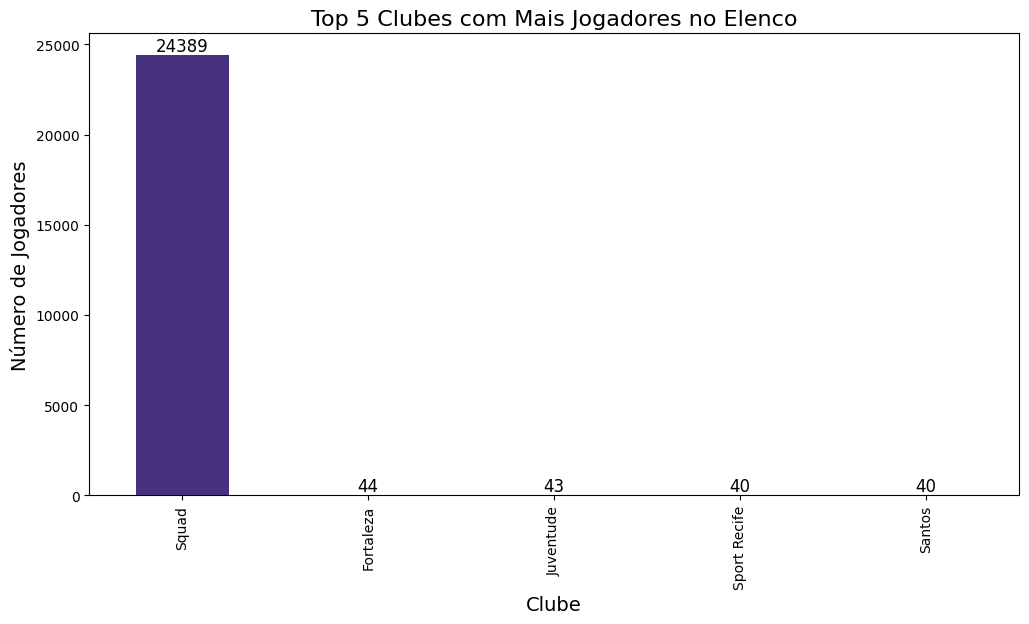

In [24]:
# Plotando os clubes com maior número de jogadores no elenco
plt.figure(figsize=(12, 6))
top_clubes = serie_a['Squad'].value_counts().nlargest(5)
ax = top_clubes.plot(kind='bar', color=sns.color_palette("viridis"))

# Adicionar valores no topo das barras
for barra in ax.patches:
    ax.annotate(
        f'{int(barra.get_height())}',  # Valor a exibir
        (barra.get_x() + barra.get_width() / 2, barra.get_height()),  # Posição
        ha='center',  # Alinhamento horizontal
        va='bottom',  # Alinhamento vertical
        fontsize=12,  # Tamanho da fonte
        color='black'  # Cor da fonte
    )

# Adicionar título e rótulos dos eixos
ax.set_title('Top 5 Clubes com Mais Jogadores no Elenco', fontsize=16)
ax.set_xlabel('Clube', fontsize=14)
ax.set_ylabel('Número de Jogadores', fontsize=14)

# Exibir o gráfico
plt.show()

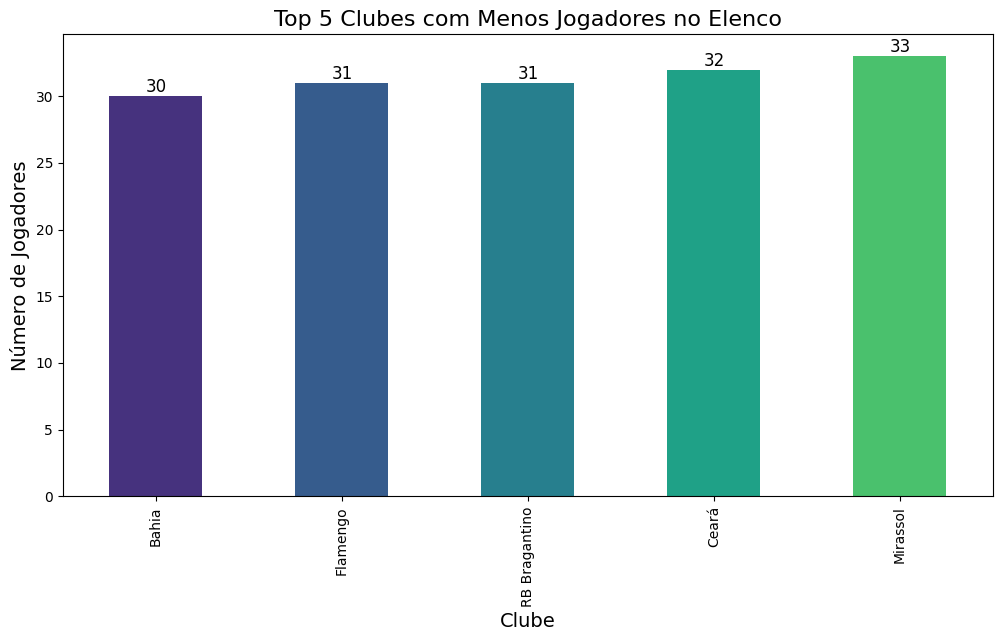

In [25]:
# Plotando os clubes com menor número de jogadores no elenco
plt.figure(figsize=(12, 6))
clubes_com_menos_jogadores = serie_a['Squad'].value_counts().nsmallest(5)
ax = clubes_com_menos_jogadores.plot(kind='bar', color=sns.color_palette("viridis"))

# Adicionar valores no topo das barras
for barra in ax.patches:
    ax.annotate(
        f'{int(barra.get_height())}',  # Valor a exibir
        (barra.get_x() + barra.get_width() / 2, barra.get_height()),  # Posição
        ha='center',  # Alinhamento horizontal
        va='bottom',  # Alinhamento vertical
        fontsize=12,  # Tamanho da fonte
        color='black'  # Cor da fonte
    )

# Adicionar título e rótulos dos eixos
ax.set_title('Top 5 Clubes com Menos Jogadores no Elenco', fontsize=16)
ax.set_xlabel('Clube', fontsize=14)
ax.set_ylabel('Número de Jogadores', fontsize=14)

# Exibir o gráfico
plt.show()

In [26]:
# Jogadores por faixa etária

Abaixo20 = serie_a[serie_a['Age'] <= 20]
Idade20_25 = serie_a[(serie_a['Age'] > 20) & (serie_a['Age'] <= 25)]
Idade25_30 = serie_a[(serie_a['Age'] > 25) & (serie_a['Age'] <= 30)]
Acima30 = serie_a[serie_a['Age'] > 30]

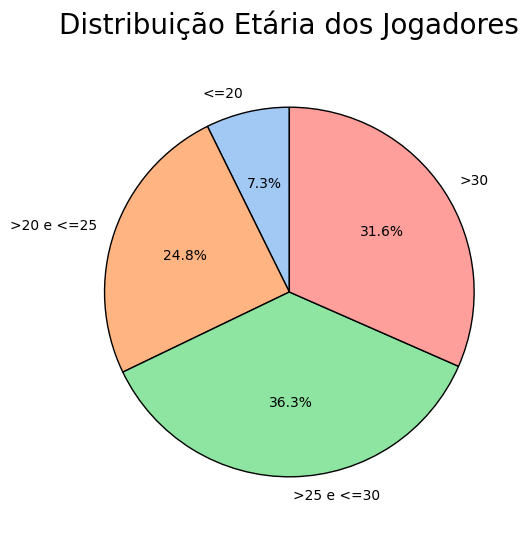

In [27]:
# Dados
x = np.array([
    Abaixo20['Player'].count(),
    Idade20_25['Player'].count(),
    Idade25_30['Player'].count(),
    Acima30['Player'].count()
])
rotulos = ["<=20", ">20 e <=25", ">25 e <=30", ">30"] 

# Criar paleta de cores personalizada
cores = sns.color_palette("pastel")

# Plotar gráfico de pizza
plt.figure(figsize=(10, 6))  # Ajustar tamanho da figura
plt.pie(
    x, 
    labels=rotulos, 
    autopct="%.1f%%", 
    colors=cores, 
    startangle=90,  # Rotacionar para começar no topo
    wedgeprops={'edgecolor': 'black'}  # Adicionar borda para melhor contraste
)
plt.title('Distribuição Etária dos Jogadores', fontsize=20, pad=20)  # Título traduzido + espaçamento

# Exibir o gráfico
plt.show()

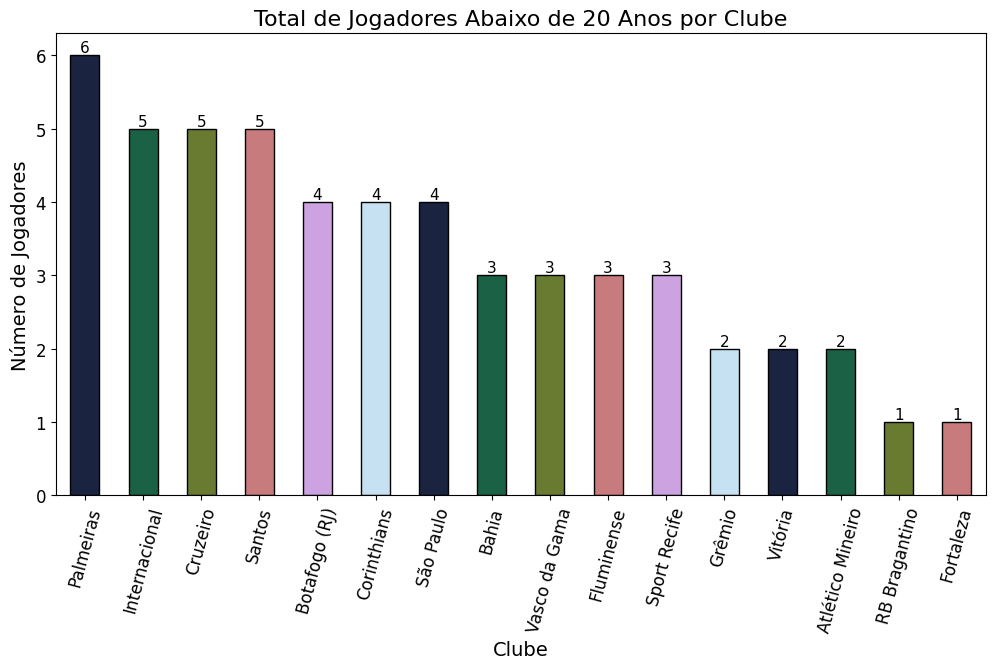

In [28]:
# Filtrar jogadores com menos de 20 anos
jogadores_abaixo_20 = serie_a[serie_a['Age'] < 20]

# Contar jogadores abaixo de 20 anos em cada clube
contagem_abaixo_20 = jogadores_abaixo_20['Squad'].value_counts()

# Plotar os dados
plt.figure(figsize=(12, 6))
ax = contagem_abaixo_20.plot(
    kind='bar', 
    color=sns.color_palette("cubehelix"), 
    edgecolor='black'
)

# Adicionar valores no topo das barras
for barra in ax.patches:
    ax.annotate(
        f'{int(barra.get_height())}',  # Exibir a contagem
        (barra.get_x() + barra.get_width() / 2, barra.get_height()),  # Posição no topo da barra
        ha='center', 
        va='bottom', 
        fontsize=11, 
        color='black'
    )

# Adicionar título e rótulos dos eixos
ax.set_title('Total de Jogadores Abaixo de 20 Anos por Clube', fontsize=16)
ax.set_xlabel('Clube', fontsize=14)
ax.set_ylabel('Número de Jogadores', fontsize=14)

# Rotacionar rótulos do eixo X para melhor legibilidade
plt.xticks(rotation=75, fontsize=12)
plt.yticks(fontsize=12)

# Exibir o gráfico
plt.show()

In [29]:
# Jogadores abaixo de 20 anos no Internacional

jogadores_abaixo_20[jogadores_abaixo_20['Squad'] == 'Internacional']

,Player,Nation,Pos,Squad,Age,Born,MP,Starts,Min,90s,...,Save%,W,D,L,CS,CS%,PKA,PKsv,PKm,Save%.1
224,Gabriel Carvalho,br BRA,FW,Internacional,18.18,2007,3.0,0.0,72.0,0.8,...,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>
449,Luis Otávio,br BRA,MF,Internacional,18.53,2007,14.0,3.0,426.0,4.7,...,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>
24976,Raykkonen,br BRA,FW,Internacional,17.27,2008,5.0,0.0,98.0,1.1,...,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>
24989,Ricardo Mathias,br BRA,FW,Internacional,19.24,2006,15.0,6.0,557.0,6.2,...,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>
25094,Yago,br BRA,MF,Internacional,18.71,2007,2.0,0.0,73.0,0.8,...,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>


In [30]:
# Jogadores abaixo de 20 anos no Palmeiras

jogadores_abaixo_20[jogadores_abaixo_20['Squad'] == 'Palmeiras']

,Player,Nation,Pos,Squad,Age,Born,MP,Starts,Min,90s,...,Save%,W,D,L,CS,CS%,PKA,PKsv,PKm,Save%.1
172,Erick Belé,br BRA,MF,Palmeiras,18.75,2007,1.0,0.0,11.0,0.1,...,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>
177,Estêvão Willian,br BRA,"MF,FW",Palmeiras,18.49,2007,11.0,9.0,831.0,9.2,...,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>
445,Luighi,br BRA,FW,Palmeiras,19.48,2006,7.0,2.0,237.0,2.6,...,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>
446,Luis Benedetti,br BRA,DF,Palmeiras,19.37,2006,2.0,2.0,180.0,2.0,...,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>
447,Luis Felipe,br BRA,MF,Palmeiras,17.72,2008,1.0,0.0,5.0,0.1,...,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>
24994,Riquelme Fillipi,br BRA,FW,Palmeiras,19.1,2006,1.0,0.0,9.0,0.1,...,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>


In [31]:
# Jogadores abaixo de 20 anos no Botafogo (RJ)

jogadores_abaixo_20[jogadores_abaixo_20['Squad'] == 'Botafogo (RJ)']

,Player,Nation,Pos,Squad,Age,Born,MP,Starts,Min,90s,...,Save%,W,D,L,CS,CS%,PKA,PKsv,PKm,Save%.1
281,Huguinho,br BRA,MF,Botafogo (RJ),18.54,2007,1.0,0.0,24.0,0.3,...,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>
333,Jordan Barrera,co COL,FW,Botafogo (RJ),19.53,2006,1.0,0.0,4.0,0.0,...,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>
341,José Kadir,pa PAN,"FW,MF",Botafogo (RJ),18.26,2007,2.0,0.0,10.0,0.1,...,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>
25109,Álvaro Montoro,ar ARG,FW,Botafogo (RJ),18.51,2007,11.0,9.0,745.0,8.3,...,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>


In [32]:
# Jogadores abaixo de 20 anos no Atlético Mineiro

jogadores_abaixo_20[jogadores_abaixo_20['Squad'] == 'Atlético Mineiro']

,Player,Nation,Pos,Squad,Age,Born,MP,Starts,Min,90s,...,Save%,W,D,L,CS,CS%,PKA,PKsv,PKm,Save%.1
306,Iván Román,cl CHI,DF,Atlético Mineiro,19.28,2006,8.0,6.0,504.0,5.6,...,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>
488,Mateus Iseppe,br BRA,MF,Atlético Mineiro,19.47,2006,1.0,0.0,3.0,0.0,...,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>


In [33]:
# Ordenar clubes pela mediana de idade
clubes_ordenados = (
    serie_a.groupby('Squad')['Age'].median()
    .sort_values(ascending=False)
    .index
)

# Criar a figura
plt.figure(figsize=(14, 7))

# Criar o boxplot com clubes ordenados e paleta personalizada
sns.boxplot(
    x='Squad', 
    y='Age', 
    data=serie_a, 
    palette='viridis', 
    order=clubes_ordenados, 
    showfliers=True  # Defina como False para ocultar outliers, se desejar
)

# Adicionar linhas dos quartis para melhor interpretação
plt.axhline(serie_a['Age'].quantile(0.25), color='blue', linestyle='--', label='25º Percentil')
plt.axhline(serie_a['Age'].quantile(0.75), color='green', linestyle='--', label='75º Percentil')
plt.legend()

# Adicionar anotações com a mediana de idade de cada clube
medianas_idade = serie_a.groupby('Squad')['Age'].median()
for indice, clube in enumerate(clubes_ordenados):
    plt.text(
        indice, 
        medianas_idade[clube] + 0.5,  # Posicionar o texto um pouco acima da mediana
        f"{medianas_idade[clube]:.1f}",  # Exibir mediana com 1 casa decimal
        ha='center', 
        fontsize=10, 
        color='black'
    )

# Personalizar título e rótulos
plt.title('Distribuição de Idade dos Jogadores por Clube', fontsize=16, pad=15)
plt.xlabel('Clube', fontsize=14)
plt.ylabel('Idade', fontsize=14)

# Ajustar rótulos dos eixos para melhor legibilidade
plt.xticks(rotation=45, ha='right', fontsize=12)
plt.yticks(fontsize=12)

# Ajustar layout para evitar sobreposição
plt.tight_layout()

# Exibir o gráfico
plt.show()

C:\Users\Leonardo Barbosa\AppData\Local\Temp\ipykernel_7236\4141105579.py:12: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




TypeError: float() argument must be a string or a real number, not 'NAType'

Error in callback <function _draw_all_if_interactive at 0x000001DEBBBBEDE0> (for post_execute), with arguments args (),kwargs {}:


TypeError: float() argument must be a string or a real number, not 'NAType'

TypeError: float() argument must be a string or a real number, not 'NAType'

<Figure size 1400x700 with 1 Axes>

In [34]:
# Contar número de jogadores por clube
num_jogadores = serie_a.groupby('Squad').size()

# Calcular a média de idade por clube (soma das idades / número de jogadores)
media_idade_por_clube = (serie_a.groupby('Squad')['Age'].sum()) / num_jogadores

# Arredondar para 2 casas decimais
media_idade_por_clube = media_idade_por_clube.round(2)

# Ordenar os clubes pela média de idade (do mais velho para o mais jovem)
media_idade_por_clube.sort_values(ascending=False)

Squad
Fluminense          29.09
Fortaleza           29.06
Mirassol            29.04
Ceará               28.71
Flamengo            28.26
Juventude           28.25
Vitória             28.22
Sport Recife        27.93
Grêmio              27.78
São Paulo           27.61
Vasco da Gama       27.32
Santos              27.12
Atlético Mineiro    27.11
Cruzeiro            27.08
Internacional       26.97
Corinthians         26.65
Bahia                26.6
Botafogo (RJ)       26.48
Palmeiras           25.95
RB Bragantino        25.2
Squad                 0.0
dtype: Float64

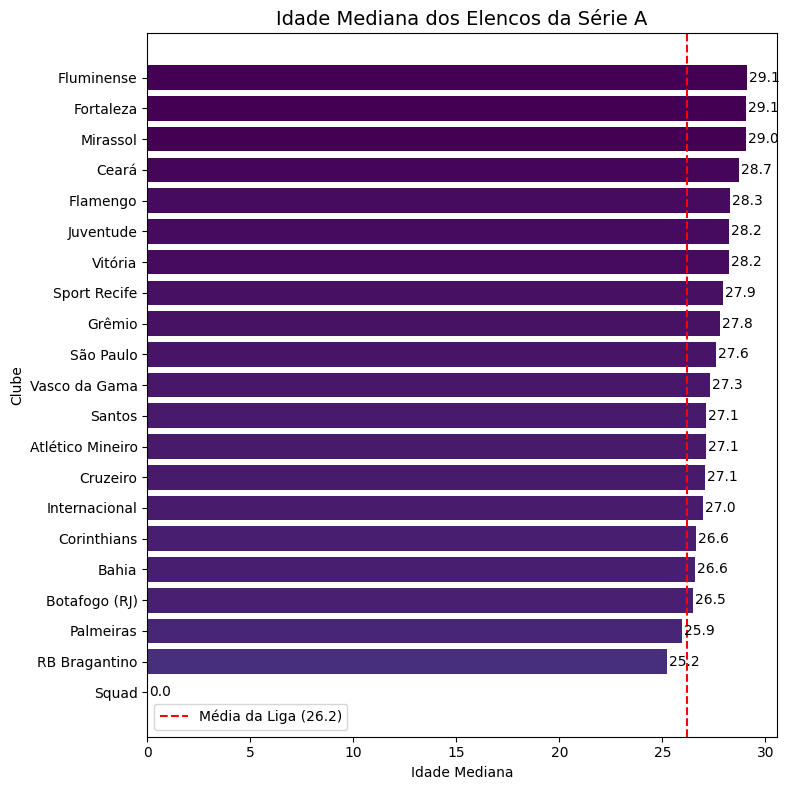

In [35]:
# Transformar em DataFrame
df_medianas = pd.DataFrame(list(media_idade_por_clube.items()), columns=["Clube", "Idade_Mediana"])

# Média da liga
media_liga = df_medianas["Idade_Mediana"].mean()

# Ordenar do mais jovem para o mais velho
df_ordenado = df_medianas.sort_values("Idade_Mediana", ascending=True)

# --- Gráfico ---
fig, ax = plt.subplots(figsize=(8, 8))

# Barras coloridas em gradiente
barras = ax.barh(
    df_ordenado["Clube"],
    df_ordenado["Idade_Mediana"],
    color=plt.cm.viridis_r(
        (df_ordenado["Idade_Mediana"] - df_ordenado["Idade_Mediana"].min()) /
        (df_ordenado["Idade_Mediana"].max() - df_ordenado["Idade_Mediana"].min())
    )
)

# Linha da média da liga
ax.axvline(media_liga, color="red", linestyle="--", label=f"Média da Liga ({media_liga:.1f})")

# Valores ao lado das barras
for barra in barras:
    largura = barra.get_width()
    ax.text(largura + 0.1, barra.get_y() + barra.get_height()/2,
            f"{largura:.1f}", va="center", fontsize=10)

# Títulos e rótulos dos eixos
ax.set_title("Idade Mediana dos Elencos da Série A", fontsize=14)
ax.set_xlabel("Idade Mediana")
ax.set_ylabel("Clube")
ax.legend()

# Ajustar layout para evitar cortes
plt.tight_layout()

# Exibir o gráfico
plt.show()

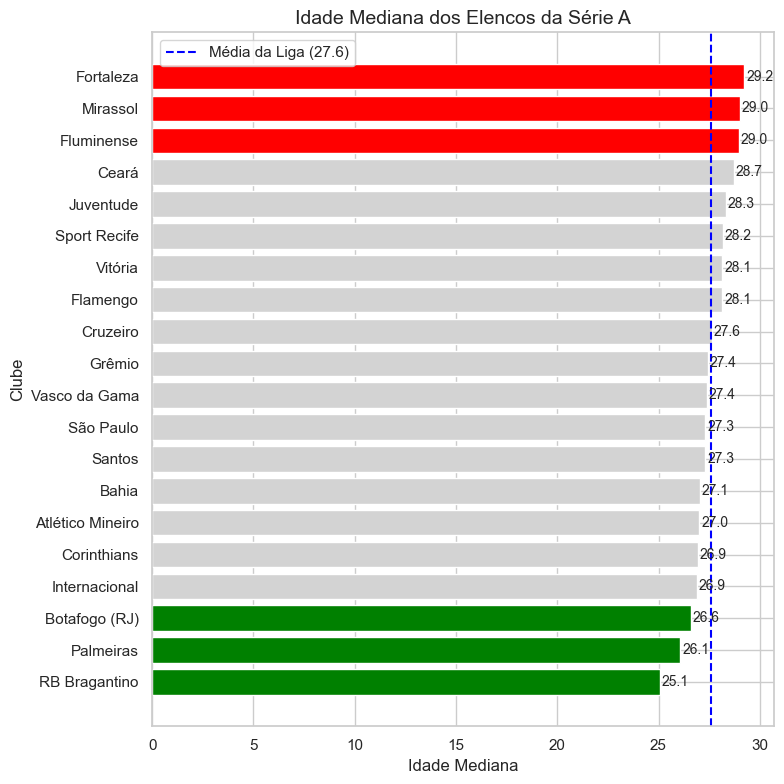

In [90]:
# Identificar top 3 clubes mais jovens e top 3 mais experientes
mais_jovens = df_ordenado.head(3)["Clube"].tolist()
mais_experientes = df_ordenado.tail(3)["Clube"].tolist()

# Definir cores para destaque
cores = []
for clube in df_ordenado["Clube"]:
    if clube in mais_jovens:
        cores.append("green")      # destaque para os mais jovens
    elif clube in mais_experientes:
        cores.append("red")        # destaque para os mais experientes
    else:
        cores.append("lightgray")  # cor neutra para os demais

# --- Gráfico ---
fig, ax = plt.subplots(figsize=(8, 8))

barras = ax.barh(df_ordenado["Clube"], df_ordenado["Idade_Mediana"], color=cores)

# Linha da média da liga
ax.axvline(media_liga, color="blue", linestyle="--", label=f"Média da Liga ({media_liga:.1f})")

# Valores ao lado das barras
for barra in barras:
    largura = barra.get_width()
    ax.text(largura + 0.1, barra.get_y() + barra.get_height()/2,
            f"{largura:.1f}", va="center", fontsize=10)

# Títulos e rótulos dos eixos
ax.set_title("Idade Mediana dos Elencos da Série A", fontsize=14)
ax.set_xlabel("Idade Mediana")
ax.set_ylabel("Clube")
ax.legend()

# Ajustar layout
plt.tight_layout()

# Exibir o gráfico
plt.show()


C:\Users\Leonardo Barbosa\AppData\Local\Temp\ipykernel_14252\2532815054.py:9: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




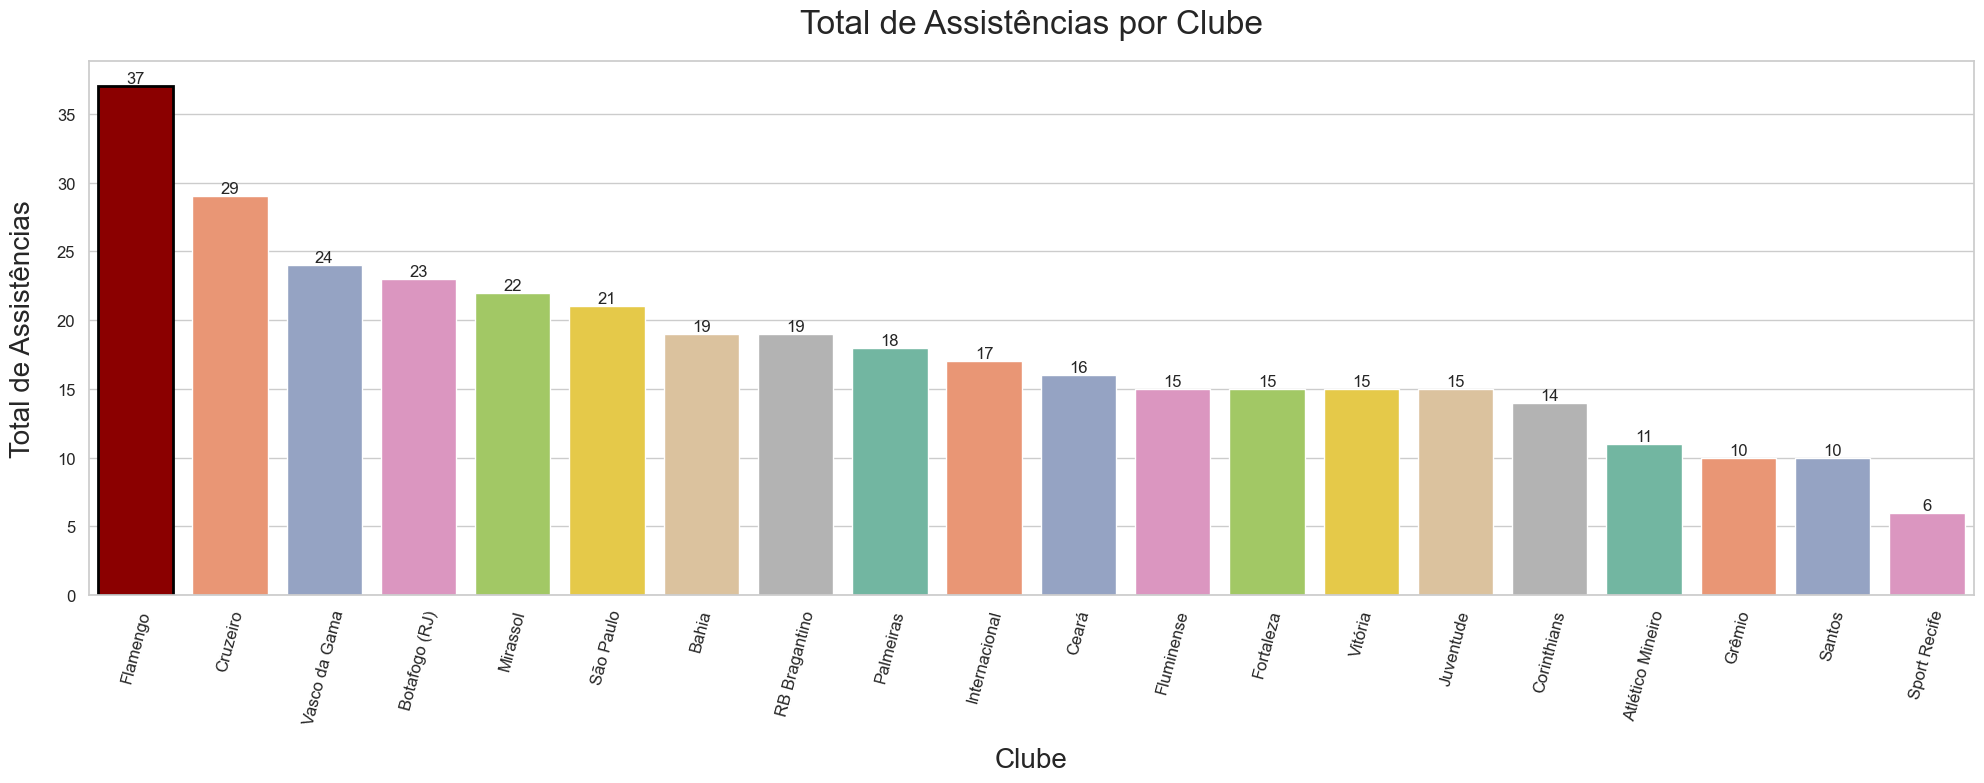

In [93]:
# Total de assistências por clube
Assistencias_por_clube = pd.DataFrame(serie_a.groupby('Squad', as_index=False)['Ast'].sum())

# Definir tema e tamanho da figura
sns.set_theme(style='whitegrid', color_codes=True)
plt.figure(figsize=(20, 8))

# Criar gráfico de barras
ax = sns.barplot(
    x='Squad', 
    y='Ast', 
    data=Assistencias_por_clube.sort_values(by='Ast', ascending=False),  # Ordenar clubes por assistências
    palette='Set2'
)

# Adicionar anotações com os valores em cima das barras
for barra in ax.patches:
    ax.annotate(
        format(int(barra.get_height()), ','),
        (barra.get_x() + barra.get_width() / 2, barra.get_height()),  # Centralizar anotação
        ha='center', 
        va='bottom', 
        fontsize=12
    )

# Personalizar rótulos e título
ax.set_xlabel('Clube', fontsize=20, labelpad=15)
ax.set_ylabel('Total de Assistências', fontsize=20, labelpad=15)
plt.xticks(rotation=75, fontsize=12)  # Rotacionar rótulos do eixo X
plt.yticks(fontsize=12)
plt.title('Total de Assistências por Clube', fontsize=24, pad=20)

# Destacar o primeiro clube (maior número de assistências)
ax.patches[0].set_facecolor('darkred')
ax.patches[0].set_edgecolor('black')
ax.patches[0].set_linewidth(2)

# Ajustar layout e exibir
plt.tight_layout()
plt.show()

In [95]:
# Top 10 jogadores com mais assistências

top_10_assistencias = serie_a[['Player', 'Age', 'Squad', 'Ast', 'MP']].nlargest(n=10, columns='Ast')
top_10_assistencias

,Player,Age,Squad,Ast,MP
147,Giorgian De Arrascaeta,31.27,Flamengo,10.0,19.0
461,Alan Patrick,34.32,Internacional,6.0,15.0
477,Matheus Pereira,29.35,Cruzeiro,6.0,20.0
485,Lucas Piton,24.92,Vasco da Gama,5.0,19.0
424,Lucas Mugni,33.65,Ceará,5.0,19.0
305,Kaio Jorge,23.62,Cruzeiro,5.0,21.0
240,Nuno Gonçalo Moreira,26.23,Vasco da Gama,4.0,21.0
69,Alexandro Bernabei,24.96,Internacional,4.0,16.0
37,Jhon Arias,27.96,Fluminense,4.0,12.0
40,Artur,27.56,Botafogo (RJ),4.0,16.0


C:\Users\Leonardo Barbosa\AppData\Local\Temp\ipykernel_14252\4876728.py:9: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




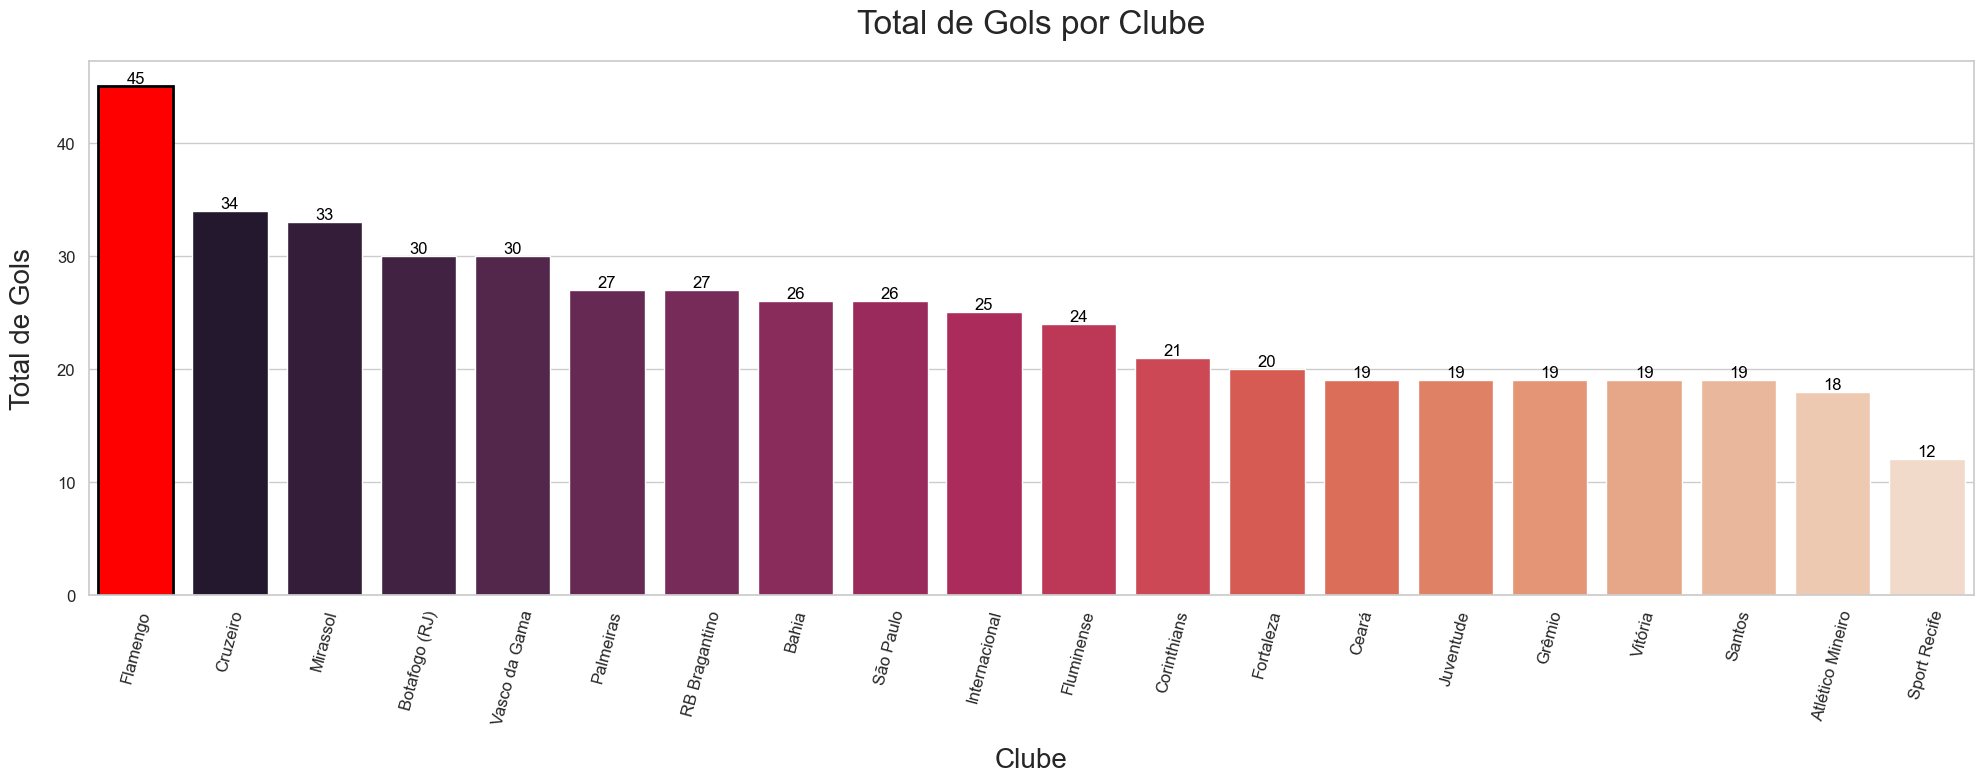

In [99]:
# Total de gols por clube
Gols_por_clube = pd.DataFrame(serie_a.groupby('Squad', as_index=False)['Gls'].sum())

# Definir tema e tamanho da figura
sns.set_theme(style='whitegrid', color_codes=True)
plt.figure(figsize=(20, 8))

# Criar gráfico de barras
ax = sns.barplot(
    x='Squad', 
    y='Gls', 
    data=Gols_por_clube.sort_values(by='Gls', ascending=False),  # Ordenar clubes por gols
    palette='rocket'
)

# Adicionar anotações com os valores em cima das barras
for barra in ax.patches:
    ax.annotate(
        format(int(barra.get_height()), ','),  # Formatar como número inteiro com separador de milhar
        (barra.get_x() + barra.get_width() / 2, barra.get_height()),  # Centralizar anotação
        ha='center', 
        va='bottom', 
        fontsize=12, 
        color='black'
    )

# Personalizar rótulos e título
ax.set_xlabel('Clube', fontsize=20, labelpad=15)
ax.set_ylabel('Total de Gols', fontsize=20, labelpad=15)
plt.xticks(rotation=75, fontsize=12)  # Rotacionar rótulos do eixo X
plt.yticks(fontsize=12)
plt.title('Total de Gols por Clube', fontsize=24, pad=20)

# Ajustar layout
plt.tight_layout()

# Destacar a primeira barra (maior número de gols)
ax.patches[0].set_facecolor('red')
ax.patches[0].set_edgecolor('black')
ax.patches[0].set_linewidth(2)

# Exibir o gráfico
plt.show()

In [101]:
import plotly.express as px
from IPython.display import HTML

# Mapeamento de cores por clube (para manter identidade visual)
cores_por_clube = {
    "Flamengo": "red",             # vermelho e preto
    "Cruzeiro": "blue",            # azul
    "Palmeiras": "green",          # verde
    "Botafogo (RJ)": "black",      # preto e branco
    "São Paulo": "darkred",        # vermelho/preto/branco
    "RB Bragantino": "crimson",    # vermelho
    "Corinthians": "gray",         # preto/branco
    "Santos": "white",             # branco/preto
    "Grêmio": "deepskyblue",       # azul/preto/branco
    "Internacional": "firebrick",  # vermelho
    "Atlético Mineiro": "black",   # preto/branco
    "Bahia": "royalblue",          # azul/vermelho/branco
    "Ceará": "dimgray",            # preto/branco
    "Fortaleza": "dodgerblue",     # azul/vermelho/branco
    "Fluminense": "darkgreen",     # verde/grená
    "Vasco da Gama": "black",      # preto/branco
    "Sport Recife": "gold",        # vermelho/preto/amarelo
    "Vitória": "darkred",          # vermelho/preto
    "Juventude": "limegreen",      # verde
    "Mirassol": "yellowgreen"      # amarelo/verde
}

# Criar gráfico de treemap: gols por clube
fig = px.treemap(
    serie_a,
    path=["Squad"],                # Agrupar por clube
    values="Gls",                  # Tamanho proporcional aos gols
    color="Squad",                 # Cor por clube
    color_discrete_map=cores_por_clube,  # Usar cores definidas acima
    width=1200,
    height=400,
    title="Total de Gols Marcados por Clube"  # Título traduzido
)

# Ajustar margens do gráfico
fig.update_layout(margin=dict(t=50, l=25, r=25, b=25))
fig.update_traces(textinfo="label+value")

# Renderizar gráfico de forma segura no notebook
HTML(fig.to_html(include_plotlyjs="cdn", full_html=False))

In [102]:
# Jogadores com mais gols

top_10_gols = serie_a[['Player', 'Age', 'Squad', 'Gls', 'Ast', 'MP', 'Pos']].nlargest(n=10, columns=['Gls'])
top_10_gols

,Player,Age,Squad,Gls,Ast,MP,Pos
305,Kaio Jorge,23.62,Cruzeiro,15.0,5.0,21.0,FW
147,Giorgian De Arrascaeta,31.27,Flamengo,12.0,10.0,19.0,"MF,FW"
634,Pablo Vegetti,36.9,Vasco da Gama,12.0,1.0,19.0,FW
470,Pedro,28.22,Flamengo,10.0,4.0,15.0,FW
514,Reinaldo,35.95,Mirassol,7.0,3.0,19.0,DF
511,Pedro Raul,28.84,Ceará,7.0,0.0,20.0,FW
318,Renato Kayser,29.56,Vitória,7.0,0.0,15.0,FW
343,José López,24.76,Palmeiras,6.0,0.0,18.0,"FW,MF"
86,Martin Braithwaite,34.26,Grêmio,6.0,1.0,17.0,FW
486,Isidro Pitta,26.07,RB Bragantino,6.0,1.0,16.0,FW


C:\Users\Leonardo Barbosa\AppData\Local\Temp\ipykernel_14252\334113283.py:12: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




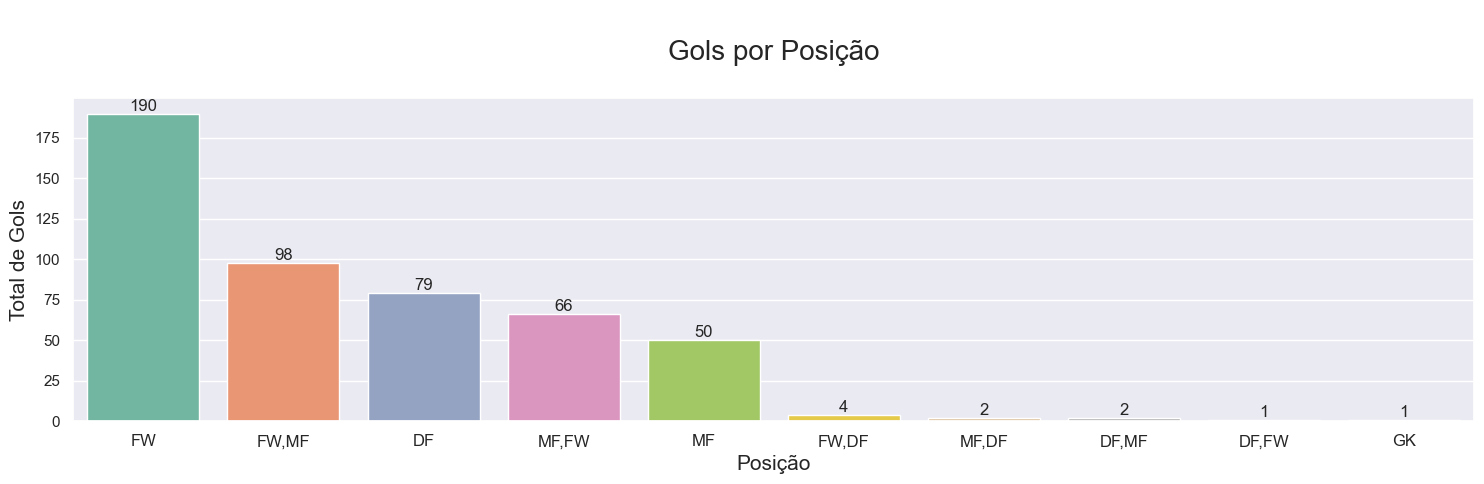

In [103]:
# Configurar estilo do Seaborn
sns.set(rc={'figure.figsize': (15, 5)})
plt.xticks(fontsize=12)

# Agrupar por posição e somar gols
serie_a_agrupado = serie_a.groupby('Pos', as_index=False)['Gls'].sum()

# Ordenar posições por total de gols (do maior para o menor)
serie_a_agrupado = serie_a_agrupado.sort_values(by='Gls', ascending=False)

# Criar gráfico de barras
p = sns.barplot(
    data=serie_a_agrupado, 
    x='Pos', 
    y='Gls', 
    palette="Set2"
)

# Adicionar valores no topo das barras
for barra in p.patches:
    p.annotate(
        format(int(barra.get_height()), ','),  # Formatar valor com separador de milhar
        (barra.get_x() + barra.get_width() / 2, barra.get_height()),  # Posicionar no topo da barra
        ha='center', 
        va='bottom', 
        fontsize=12
    )

# Adicionar título e rótulos dos eixos
p.axes.set_title("\nGols por Posição\n", fontsize=20)
p.set_xlabel("Posição", fontsize=15)
p.set_ylabel("Total de Gols", fontsize=15)

# Melhorar layout e exibir o gráfico
plt.tight_layout()
plt.show()

In [104]:
# Criar 2 novas colunas
serie_a['MinutosPorJogo'] = (serie_a['Min'] / serie_a['MP']).fillna(0).astype(int)
serie_a['GolsPorJogo'] = (serie_a['Gls'] / serie_a['MP']).fillna(0).astype(float)
print(serie_a)

      Rk            Player  Nation    Pos             Squad    Age  Born  \
448  449         Leo Ortiz  br BRA     DF          Flamengo  29.68  1996   
336  337        Lucas Lima  br BRA  MF,FW      Sport Recife  35.17  1990   
207  208    Marlon Freitas  br BRA     MF     Botafogo (RJ)  30.45  1995   
142  143       Danielzinho  br BRA     MF          Mirassol  30.84  1994   
582  583    Gustavo Scarpa  br BRA  MF,FW  Atlético Mineiro  31.67  1994   
..   ...               ...     ...    ...               ...    ...   ...   
600  601   Luis Sinisterra  co COL     MF          Cruzeiro  26.23  1999   
346  347             Lucão  br BRA     GK     RB Bragantino  24.53  2001   
675  676             Young  br BRA     GK         São Paulo  23.51  2002   
676  677  Lukas Zuccarello  br BRA     FW     Vasco da Gama  18.77  2006   
407  408      Jean Meneses  cl CHI     FW     Vasco da Gama  32.48  1993   

       MP  Starts     Min  ...  G+A-PK_90  xG_90  xAG_90  xG+xAG_90  npxG_90  \
448  20

In [114]:
# Gols por jogo
# Filtrar jogadores com mais de 10 jogos disputados

acima_10_jogos = serie_a[serie_a['MP'] > 10]
top_10_gols_por_jogo = acima_10_jogos[['Player', 'Age', 'Squad', 'MP', 'Min', 'Gls', 'GolsPorJogo']].nlargest(n=10, columns='GolsPorJogo')
top_10_gols_por_jogo

,Player,Age,Squad,MP,Min,Gls,GolsPorJogo
305,Kaio Jorge,23.62,Cruzeiro,21.0,1628.0,15.0,0.714286
470,Pedro,28.22,Flamengo,15.0,770.0,10.0,0.666667
147,Giorgian De Arrascaeta,31.27,Flamengo,19.0,1414.0,12.0,0.631579
634,Pablo Vegetti,36.9,Vasco da Gama,19.0,1549.0,12.0,0.631579
318,Renato Kayser,29.56,Vitória,15.0,1153.0,7.0,0.466667
102,Germán Cano,37.6,Fluminense,13.0,967.0,5.0,0.384615
6,Yuri Alberto,24.48,Corinthians,13.0,906.0,5.0,0.384615
486,Isidro Pitta,26.07,RB Bragantino,16.0,697.0,6.0,0.375000
514,Reinaldo,35.95,Mirassol,19.0,1631.0,7.0,0.368421
32,Michel Araujo,28.95,Bahia,11.0,293.0,4.0,0.363636


In [116]:
top_10_gols_por_jogo[['Player', 'Squad', 'MP', 'Gls', 'GolsPorJogo']].style \
    .set_caption("Top 10 Jogadores em Gols por Jogo (Mín. 11 Jogos)") \
    .format({'GolsPorJogo': "{:.2f}"}) \
    .set_properties(**{'text-align': 'center', 'background-color': "#070707"})

,Player,Squad,MP,Gls,GolsPorJogo
305,Kaio Jorge,Cruzeiro,21.000000,15.000000,0.71
470,Pedro,Flamengo,15.000000,10.000000,0.67
147,Giorgian De Arrascaeta,Flamengo,19.000000,12.000000,0.63
634,Pablo Vegetti,Vasco da Gama,19.000000,12.000000,0.63
318,Renato Kayser,Vitória,15.000000,7.000000,0.47
102,Germán Cano,Fluminense,13.000000,5.000000,0.38
6,Yuri Alberto,Corinthians,13.000000,5.000000,0.38
486,Isidro Pitta,RB Bragantino,16.000000,6.000000,0.38
514,Reinaldo,Mirassol,19.000000,7.000000,0.37
32,Michel Araujo,Bahia,11.000000,4.000000,0.36


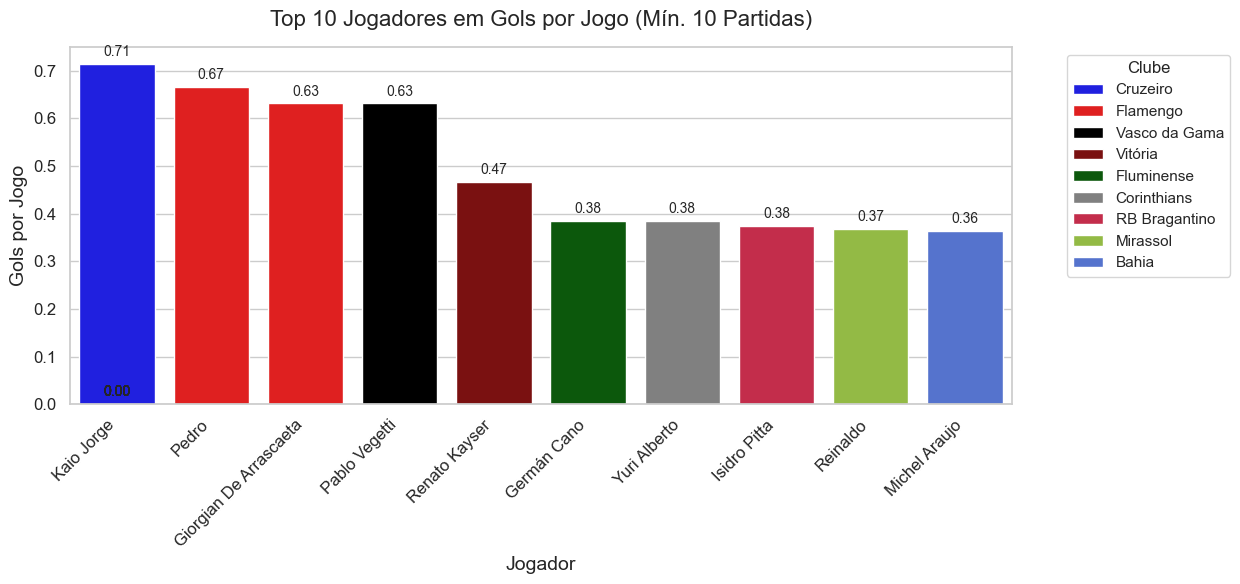

In [122]:
# Filtrar jogadores com mais de 10 partidas jogadas
acima_10_partidas = serie_a[serie_a['MP'] > 10]

# Selecionar os 10 jogadores com melhor desempenho em GolsPorJogo
top_10_gols_por_jogo = acima_10_partidas[['Player', 'Squad', 'GolsPorJogo', 'MP', 'Gls']].nlargest(n=10, columns='GolsPorJogo')

# Plotar gráfico
plt.figure(figsize=(12, 6))
sns.set_theme(style="whitegrid")


# Criar gráfico
ax = sns.barplot(
    data=top_10_gols_por_jogo,
    x='Player',
    y='GolsPorJogo',
    hue='Squad',
    palette=cores_por_clube,
    dodge=False
)

# Adicionar valores no topo das barras (corrigido)
for barra in ax.patches:
    valor = barra.get_height()
    valor_formatado = f"{valor:.2f}"  # Garante 2 casas decimais
    ax.annotate(
        valor_formatado,
        (barra.get_x() + barra.get_width() / 2, barra.get_height() + 0.01),
        ha='center', va='bottom', fontsize=10
    )

# Personalizar título e rótulos
ax.set_title('Top 10 Jogadores em Gols por Jogo (Mín. 10 Partidas)', fontsize=16, pad=15)
ax.set_xlabel('Jogador', fontsize=14)
ax.set_ylabel('Gols por Jogo', fontsize=14)
plt.xticks(rotation=45, ha='right', fontsize=12)
plt.yticks(fontsize=12)

# Legenda fora do gráfico
ax.legend(title="Clube", bbox_to_anchor=(1.05, 1), loc='upper left')

# Ajustar layout
plt.tight_layout()
plt.subplots_adjust(right=0.85)
plt.show()

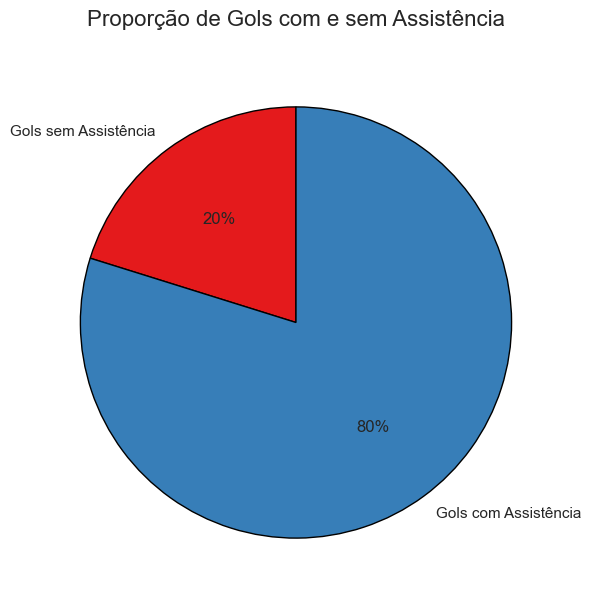

In [123]:
# Dados para o gráfico de pizza
assistencias = serie_a['Ast'].sum()
dados = [Total_Gols - assistencias, assistencias]
rotulos = ['Gols sem Assistência', 'Gols com Assistência']
cores = sns.color_palette('Set1')

# Criar gráfico de pizza
plt.figure(figsize=(14, 7))
plt.pie(
    dados, 
    labels=rotulos, 
    colors=cores, 
    autopct='%.0f%%', 
    startangle=90,  # Iniciar o gráfico no topo
    wedgeprops={'edgecolor': 'black'}  # Adicionar bordas pretas para melhor contraste
)

# Adicionar título
plt.title('Proporção de Gols com e sem Assistência', fontsize=16, pad=20)

# Exibir o gráfico
plt.show()

In [125]:
import plotly.express as px
from IPython.display import HTML

# Filtrar atacantes com pelo menos 900 minutos jogados
atacantes = serie_a[serie_a['Min'] >= 900]

# Criando o gráfico de dispersão
fig = px.scatter(
    atacantes,
    x="Gls_90",      # Eixo X: Gols por 90 minutos
    y="xG_90",       # Eixo Y: xG (Expected Goals) por 90 minutos
    text="Player",   # Exibir nome dos jogadores nos pontos
    title="Relação entre Gols Marcados e xG por 90 Minutos",
    labels={
        "xG_90": "xG por 90 min (Gols Esperados)",
        "Gls_90": "Gols por 90 min"
    },
    template="plotly_white"
)

# Adicionar linha de referência: xG = Gols
fig.add_shape(
    type="line", line=dict(dash='dash', color='gray'),
    x0=atacantes['Gls_90'].min(), y0=atacantes['Gls_90'].min(),
    x1=atacantes['Gls_90'].max(), y1=atacantes['Gls_90'].max()
)

# Adicionar anotação na linha
fig.add_annotation(
    x=atacantes['Gls_90'].max() - 0.5,
    y=atacantes['Gls_90'].max() - 0.5,
    text="xG = Gols",
    showarrow=False,
    font=dict(size=12, color="gray")
)


# Ajustando posição do texto (nome dos jogadores)
fig.update_traces(textposition="top center")

# Exibir gráfico inline sem depender de renderizador externo
HTML(fig.to_html(include_plotlyjs="cdn", full_html=False))

C:\Users\Leonardo Barbosa\AppData\Local\Temp\ipykernel_14252\1607325876.py:13: FutureWarning:



The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.


C:\Users\Leonardo Barbosa\AppData\Local\Temp\ipykernel_14252\1607325876.py:13: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.


C:\Users\Leonardo Barbosa\AppData\Local\Temp\ipykernel_14252\1607325876.py:38: FutureWarning:



The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.




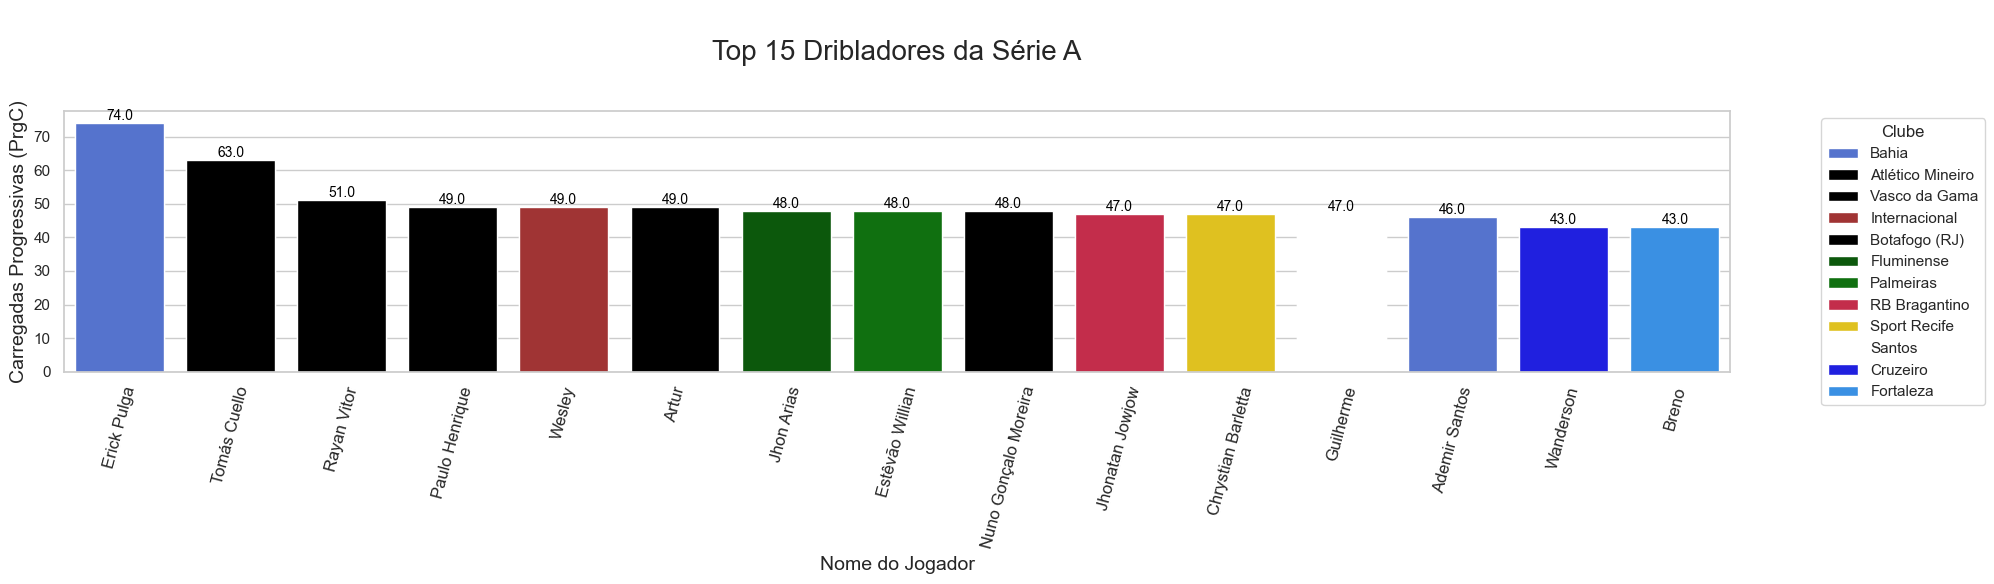

In [127]:
# Ordenar o dataset por 'PrgC' em ordem decrescente
serie_a = serie_a.sort_values(by='PrgC', ascending=False)

# Selecionar os 15 melhores jogadores
top_dribladores = serie_a[:15]

# Configurar estilo do Seaborn e tamanho da figura
sns.set(rc={'figure.figsize': (20, 6)})
sns.set_theme(style="whitegrid")
plt.xticks(fontsize=12, rotation=75)

# Criar gráfico de barras sem barras de erro
ax = sns.barplot(
    x="Player", 
    y="PrgC", 
    data=top_dribladores, 
    palette="cividis", 
    capsize=0.2, 
    ci=None  # Desativar intervalos de confiança (barras de erro)
)

# Adicionar valores no topo das barras
for barra in ax.patches:
    ax.annotate(
        format(barra.get_height(), '.1f'), 
        (barra.get_x() + barra.get_width() / 2, barra.get_height()), 
        ha='center', 
        va='bottom', 
        fontsize=10, 
        color='black'
    )

# Adicionar título e rótulos dos eixos
ax.set_title("\nTop 15 Dribladores da Série A\n", fontsize=20, pad=15)
ax.set_xlabel("Nome do Jogador", fontsize=14)
ax.set_ylabel("Carregadas Progressivas (PrgC)", fontsize=14)

ax = sns.barplot(
    x="Player", 
    y="PrgC", 
    data=top_dribladores, 
    hue="Squad",          # Agrupar por clube
    palette=cores_por_clube,  # Usar cores definidas anteriormente
    dodge=False,
    ci=None
)

# Mover legenda para fora
ax.legend(title="Clube", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.subplots_adjust(right=0.85)


# Ajustar layout e exibir o gráfico
plt.tight_layout()
plt.show()

C:\Users\Leonardo Barbosa\AppData\Local\Temp\ipykernel_14252\1197667046.py:13: FutureWarning:



The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.


C:\Users\Leonardo Barbosa\AppData\Local\Temp\ipykernel_14252\1197667046.py:13: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.


C:\Users\Leonardo Barbosa\AppData\Local\Temp\ipykernel_14252\1197667046.py:39: FutureWarning:



The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.




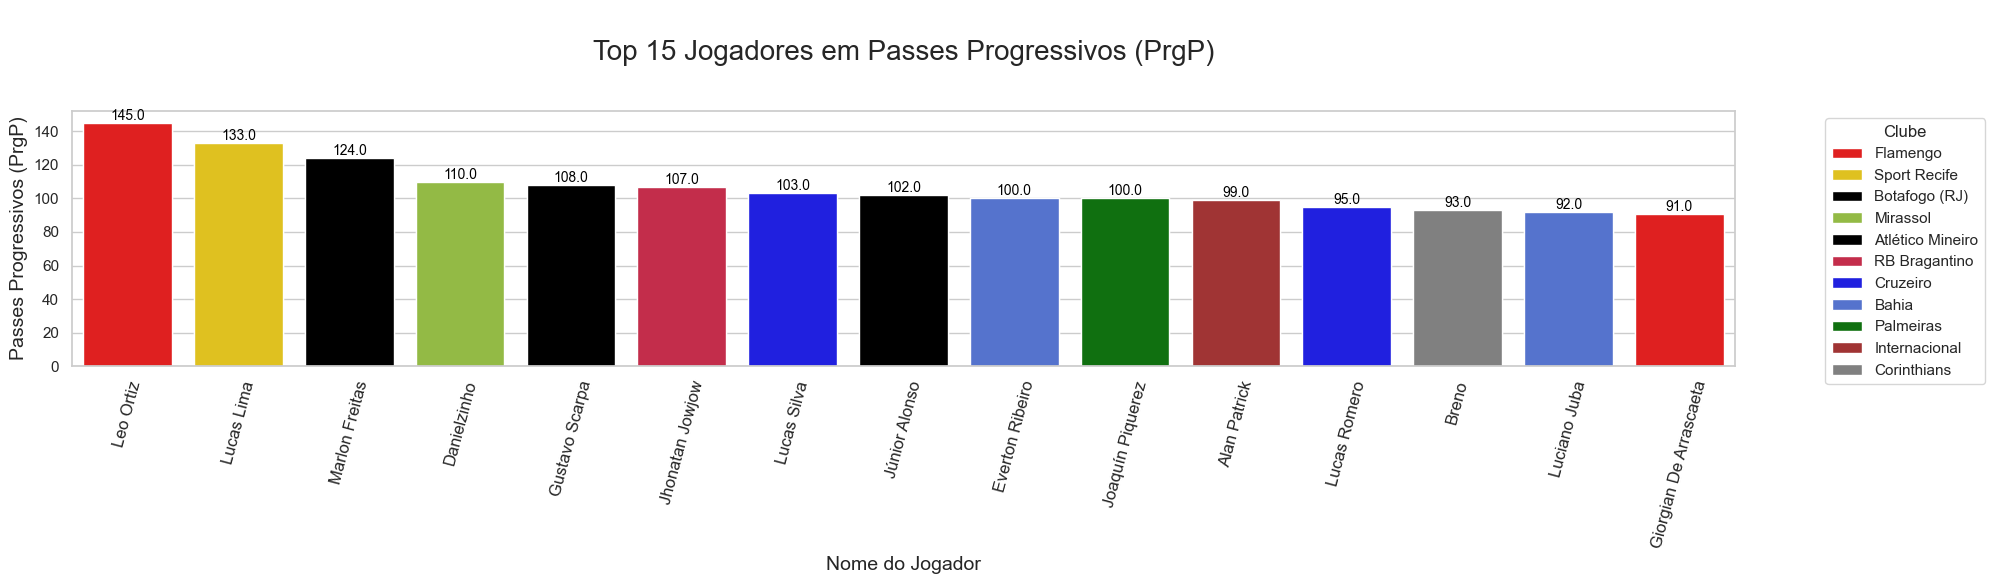

In [129]:
# Ordenar o dataset por 'PrgP' em ordem decrescente
serie_a = serie_a.sort_values(by='PrgP', ascending=False)

# Selecionar os 15 melhores jogadores
top_passadores = serie_a[:15]

# Configurar estilo do Seaborn e tamanho da figura
sns.set(rc={'figure.figsize': (20, 6)})
sns.set_theme(style="whitegrid")
plt.xticks(fontsize=12, rotation=75)  # Rotacionar rótulos do eixo X para melhor legibilidade

# Criar gráfico de barras
ax = sns.barplot(
    x="Player", 
    y="PrgP", 
    data=top_passadores, 
    palette="cividis", 
    capsize=0.2, 
    ci=None  # Desativar intervalos de confiança (barras de erro)
)

# Adicionar valores no topo das barras
for barra in ax.patches:
    ax.annotate(
        format(barra.get_height(), '.1f'),  # Exibir valor com uma casa decimal
        (barra.get_x() + barra.get_width() / 2, barra.get_height()),  # Posicionar no topo da barra
        ha='center', 
        va='bottom', 
        fontsize=10, 
        color='black'
    )

# Adicionar título e rótulos dos eixos
ax.set_title("\nTop 15 Jogadores em Passes Progressivos (PrgP)\n", fontsize=20, pad=15)
ax.set_xlabel("Nome do Jogador", fontsize=14)
ax.set_ylabel("Passes Progressivos (PrgP)", fontsize=14)


ax = sns.barplot(
    x="Player", 
    y="PrgP", 
    data=top_passadores, 
    hue="Squad",          # Agrupar por clube
    palette=cores_por_clube,  # Usar cores definidas anteriormente
    dodge=False,
    ci=None
)

# Mover legenda para fora do gráfico
ax.legend(title="Clube", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.subplots_adjust(right=0.85)  # Dar espaço para a legenda


# Ajustar layout e exibir o gráfico
plt.tight_layout()
plt.show()

In [130]:
serie_a.columns.to_list()

['Rk',
 'Player',
 'Nation',
 'Pos',
 'Squad',
 'Age',
 'Born',
 'MP',
 'Starts',
 'Min',
 '90s',
 'Gls',
 'Ast',
 'G+A',
 'G-PK',
 'PK',
 'PKatt',
 'CrdY',
 'CrdR',
 'xG',
 'npxG',
 'xAG',
 'npxG+xAG',
 'PrgC',
 'PrgP',
 'PrgR',
 'Gls_90',
 'Ast_90',
 'G+A_90',
 'G-PK_90',
 'G+A-PK_90',
 'xG_90',
 'xAG_90',
 'xG+xAG_90',
 'npxG_90',
 'npxG+xAG_90',
 'MinsPerMatch',
 'GoalsPerMatch',
 'MinutosPorJogo',
 'GolsPorJogo']

C:\Users\Leonardo Barbosa\AppData\Local\Temp\ipykernel_14252\337552084.py:21: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




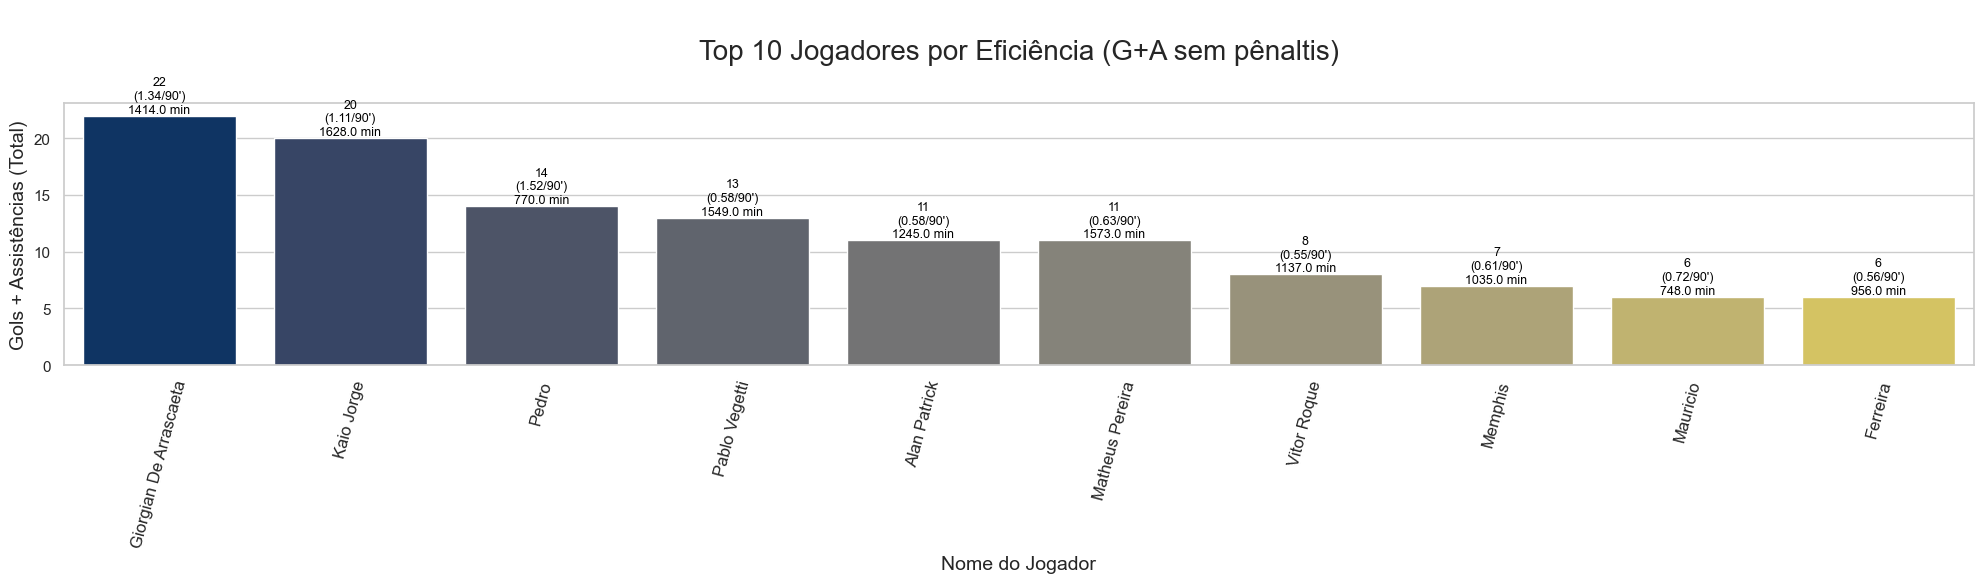

In [137]:
# Criar coluna G+A (se ainda não existir)
serie_a['G+A'] = serie_a['Gls'] + serie_a['Ast']

# Filtrar jogadores com pelo menos 8 jogos (90s >= 8)
serie_a_filtrada = serie_a[serie_a['90s'] >= 8]

# Ordenar por eficiência (G+A-PK_90) — para selecionar os mais eficientes
serie_a_ordenada = serie_a_filtrada.sort_values(by='G+A-PK_90', ascending=False)

# Selecionar os 10 melhores
top_jogadores = serie_a_ordenada.head(10)

# Reordenar por G+A total (para exibição visual)
top_jogadores_ordem_plot = top_jogadores.sort_values(by='G+A', ascending=False)

# Configurar estilo
sns.set_theme(style="whitegrid", rc={'figure.figsize': (20, 6)})
plt.xticks(fontsize=12, rotation=75)

# Criar gráfico
ax = sns.barplot(
    x="Player",
    y="G+A",
    data=top_jogadores_ordem_plot,
    palette="cividis"
)

# Adicionar valores totais e eficiência
for i, barra in enumerate(ax.patches):
    jogador = top_jogadores_ordem_plot.iloc[i]
    valor_total = barra.get_height()
    eficiencia = jogador['G+A-PK_90']
    minutos = jogador['Min']
    
    ax.annotate(
        f"{valor_total:.0f}\n({eficiencia:.2f}/90')\n{minutos} min",
        (barra.get_x() + barra.get_width() / 2, valor_total),
        ha='center', va='bottom', fontsize=9, color='black'
    )

# Título e rótulos
ax.set_title("\nTop 10 Jogadores por Eficiência (G+A sem pênaltis)\n", fontsize=20, pad=10)
ax.set_xlabel("Nome do Jogador", fontsize=14)
ax.set_ylabel("Gols + Assistências (Total)", fontsize=14)

plt.tight_layout()
plt.show()

C:\Users\Leonardo Barbosa\AppData\Local\Temp\ipykernel_14252\159444292.py:9: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.


C:\Users\Leonardo Barbosa\AppData\Local\Temp\ipykernel_14252\159444292.py:32: UserWarning:

set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.



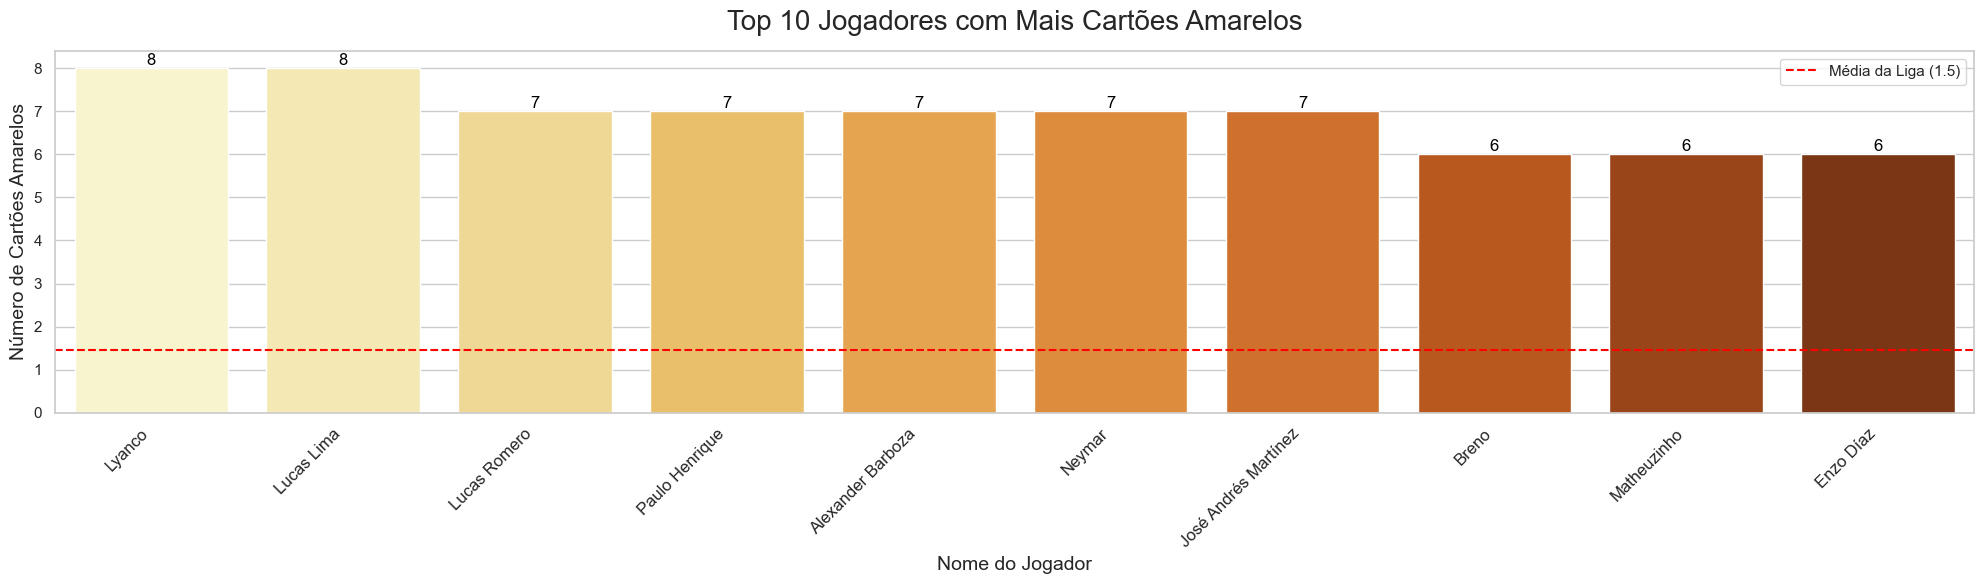

In [141]:
# Ordenar o dataset por cartões amarelos e selecionar os 10 jogadores com mais cartões
serie_a_amarelos = serie_a.sort_values(by='CrdY', ascending=False).head(10)

# Configurar tamanho da figura e estilo
plt.figure(figsize=(20, 6))
sns.set_theme(style="whitegrid")

# Criar gráfico de barras
ax = sns.barplot(
    x=serie_a_amarelos['Player'], 
    y=serie_a_amarelos['CrdY'], 
    palette="YlOrBr"  # Paleta de cores em gradiente amarelo/laranja (temática de cartões)
)

# Adicionar anotações com o número de cartões amarelos
for barra in ax.patches:
    ax.annotate(
        f'{int(barra.get_height())}',  # Exibir contagem de cartões como número inteiro
        (barra.get_x() + barra.get_width() / 2, barra.get_height()),  # Posicionar acima da barra
        ha='center', 
        va='bottom', 
        fontsize=12, 
        color='black'
    )

# Personalizar título e rótulos dos eixos
ax.set_title('Top 10 Jogadores com Mais Cartões Amarelos', fontsize=20, pad=15)
ax.set_xlabel('Nome do Jogador', fontsize=14)
ax.set_ylabel('Número de Cartões Amarelos', fontsize=14)

# Rotacionar rótulos do eixo X para melhor legibilidade
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right', fontsize=12)

media_liga = serie_a['CrdY'].mean()
ax.axhline(media_liga, color='red', linestyle='--', label=f'Média da Liga ({media_liga:.1f})')
ax.legend()

# Ajustar layout e exibir o gráfico
plt.tight_layout()
plt.show()

C:\Users\Leonardo Barbosa\AppData\Local\Temp\ipykernel_14252\1564836890.py:9: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.


C:\Users\Leonardo Barbosa\AppData\Local\Temp\ipykernel_14252\1564836890.py:41: UserWarning:

set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.



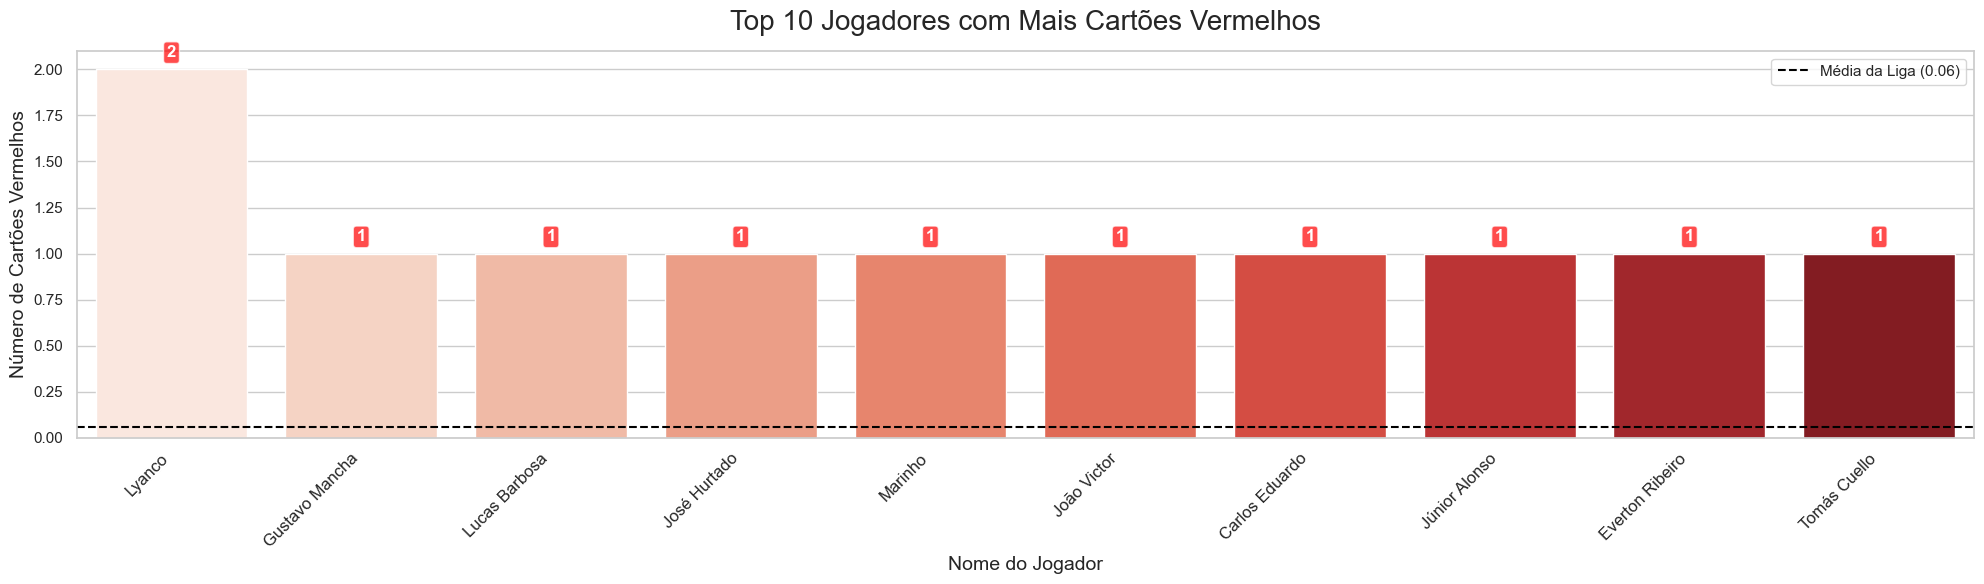

In [144]:
# Ordenar o dataset por cartões vermelhos e selecionar os 10 jogadores com mais cartões
serie_a_vermelhos = serie_a.sort_values(by='CrdR', ascending=False).head(10)

# Configurar tamanho da figura e estilo
plt.figure(figsize=(20, 6))
sns.set_theme(style="whitegrid")

# Criar gráfico de barras
ax = sns.barplot(
    x=serie_a_vermelhos['Player'], 
    y=serie_a_vermelhos['CrdR'], 
    palette="Reds"  # Paleta de gradiente vermelho
)

# Adicionar anotações com o número de cartões vermelhos — POSICIONADAS ACIMA DA BARRA
for barra in ax.patches:
    altura = barra.get_height()
    # Posicionar o texto UM POUCO ACIMA da barra para melhor visibilidade
    ax.annotate(
        f'{int(altura)}',  # Número inteiro de cartões
        (barra.get_x() + barra.get_width() / 2, altura + 0.05),  # 👈 Deslocamento vertical +0.05
        ha='center', 
        va='bottom', 
        fontsize=12, 
        color='white',
        fontweight='bold',
        bbox=dict(boxstyle="round,pad=0.2", facecolor="red", alpha=0.7)  # Fundo arredondado para destacar
    )

# Personalizar título e rótulos dos eixos
ax.set_title('Top 10 Jogadores com Mais Cartões Vermelhos', fontsize=20, pad=15)
ax.set_xlabel('Nome do Jogador', fontsize=14)
ax.set_ylabel('Número de Cartões Vermelhos', fontsize=14)

# Adicionar linha da média da liga
media_liga = serie_a['CrdR'].mean()
ax.axhline(media_liga, color='black', linestyle='--', label=f'Média da Liga ({media_liga:.2f})')
ax.legend()

# Rotacionar rótulos do eixo X
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right', fontsize=12)

# Ajustar layout e exibir
plt.tight_layout()
plt.show()

## Melhores Jogadores

In [145]:
# Quantos jogos cada clube já disputou
jogos_por_time = serie_a.groupby("Squad")["MP"].max().sort_values(ascending=False)

print(jogos_por_time)


Squad
Ceará               21.0
Grêmio              21.0
Flamengo            21.0
Cruzeiro            21.0
São Paulo           21.0
Vasco da Gama       21.0
RB Bragantino       21.0
Vitória             21.0
Santos              21.0
Botafogo (RJ)       20.0
Atlético Mineiro    20.0
Bahia               20.0
Corinthians         20.0
Mirassol            20.0
Juventude           20.0
Fluminense          20.0
Sport Recife        20.0
Fortaleza           19.0
Internacional       19.0
Palmeiras           19.0
Name: MP, dtype: Float64


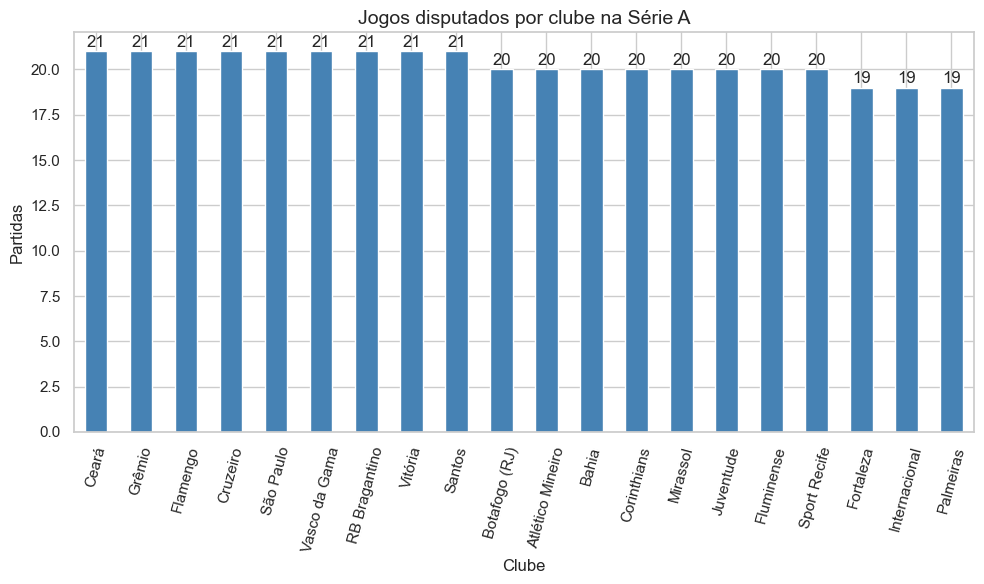

In [146]:
import matplotlib.pyplot as plt

jogos_por_time = serie_a.groupby("Squad")["MP"].max().sort_values(ascending=False)

# Plot
fig, ax = plt.subplots(figsize=(10,6))
jogos_por_time.plot(kind="bar", color="steelblue", ax=ax)

# Adicionar rótulos em cima
for i, v in enumerate(jogos_por_time):
    ax.text(i, v + 0.1, str(int(v)), ha='center', va='bottom')

ax.set_title("Jogos disputados por clube na Série A", fontsize=14)
ax.set_ylabel("Partidas")
ax.set_xlabel("Clube")
plt.xticks(rotation=75)
plt.tight_layout()
plt.show()


In [147]:
# Top jogadores com mais jogos
top_jogadores = serie_a.sort_values("Min", ascending=False)[["Player","Pos","Squad","MP","Min"]]

print(top_jogadores.head(15))


              Player Pos          Squad    MP     Min
654      Tiago Volpi  GK         Grêmio  21.0  1890.0
87    Gabriel Brazão  GK         Santos  21.0  1890.0
117           Cássio  GK       Cruzeiro  21.0  1890.0
562    Agustín Rossi  GK       Flamengo  21.0  1890.0
93    Fabrício Bruno  DF       Cruzeiro  21.0  1890.0
35     Lucas Arcanjo  GK        Vitória  21.0  1890.0
484     Rafael Pires  GK      São Paulo  21.0  1890.0
153        Dieguinho  MF          Ceará  21.0  1836.0
251     Lucas Halter  DF        Vitória  20.0  1800.0
298           Jemmes  DF       Mirassol  20.0  1800.0
182            Fábio  GK     Fluminense  20.0  1800.0
293       Léo Jardim  GK  Vasco da Gama  20.0  1795.0
287           Jadson  MF      Juventude  20.0  1791.0
359  Willian Machado  DF          Ceará  20.0  1779.0
314            Kaiki  DF       Cruzeiro  20.0  1776.0


In [148]:
# Média de jogos por posição
jogos_por_pos = serie_a.groupby("Pos")["MP"].mean().sort_values(ascending=False)
print(jogos_por_pos.round(2))


Pos
FW,MF    10.77
MF,FW    10.75
MF,DF    10.67
GK       10.07
MF        9.53
FW,DF      9.5
FW        9.48
DF        9.36
DF,FW     7.75
DF,MF     4.88
Name: MP, dtype: Float64


In [149]:
import pandas as pd

def top_n_jogos_por_pos(df, n=5, min_minutos=0):
    d = df.copy()

    # garantir tipos numéricos
    d["MP"]  = pd.to_numeric(d["MP"], errors="coerce")
    d["Min"] = pd.to_numeric(d["Min"], errors="coerce")

    # normalizar posição (pega a primeira da lista)
    d["Pos_simple"] = (
        d["Pos"].astype(str)
                .str.split(",|/|;")
                .str[0]
                .str.strip()
    )

    # filtro opcional por minutos
    if min_minutos > 0:
        d = d[d["Min"] >= min_minutos]

    # ordenar por posição, depois MP e Min (desempate)
    d = d.sort_values(["Pos_simple", "MP", "Min"], ascending=[True, False, False])

    # pegar top N por posição
    out = (d.groupby("Pos_simple")
             .head(n)[["Pos_simple", "Player", "Squad", "MP", "Min"]]
             .reset_index(drop=True))
    return out

top5_por_pos = top_n_jogos_por_pos(serie_a, n=5, min_minutos=0)

for pos, bloco in top5_por_pos.groupby("Pos_simple"):
    print(f"\n=== {pos} ===")
    print(bloco.drop(columns="Pos_simple").reset_index(drop=True).to_string(index=False))



=== DF ===
         Player    Squad    MP     Min
 Fabrício Bruno Cruzeiro  21.0  1890.0
   Lucas Halter  Vitória  20.0  1800.0
         Jemmes Mirassol  20.0  1800.0
Willian Machado    Ceará  20.0  1779.0
          Kaiki Cruzeiro  20.0  1776.0

=== FW ===
              Player         Squad    MP     Min
     Antonio Galeano         Ceará  21.0  1760.0
          Kaio Jorge      Cruzeiro  21.0  1628.0
Nuno Gonçalo Moreira Vasco da Gama  21.0  1558.0
           Wanderson      Cruzeiro  21.0  1517.0
          Pedro Raul         Ceará  20.0  1713.0

=== GK ===
        Player    Squad    MP     Min
 Lucas Arcanjo  Vitória  21.0  1890.0
Gabriel Brazão   Santos  21.0  1890.0
   Tiago Volpi   Grêmio  21.0  1890.0
        Cássio Cruzeiro  21.0  1890.0
 Agustín Rossi Flamengo  21.0  1890.0

=== MF ===
      Player         Squad    MP     Min
   Dieguinho         Ceará  21.0  1836.0
 Lucas Silva      Cruzeiro  21.0  1684.0
Eric Ramires RB Bragantino  21.0  1297.0
      Jadson     Juventude  20.0

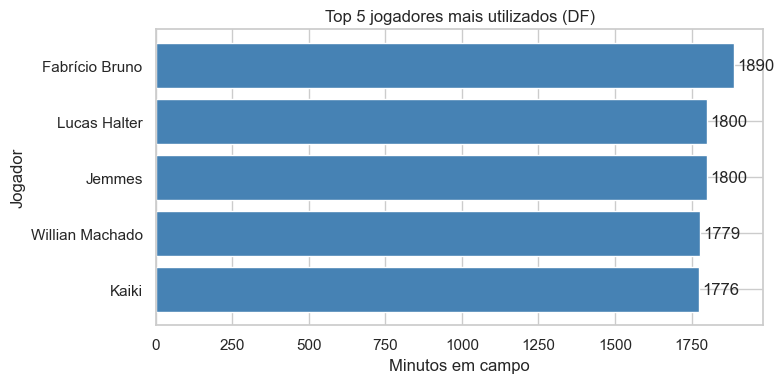

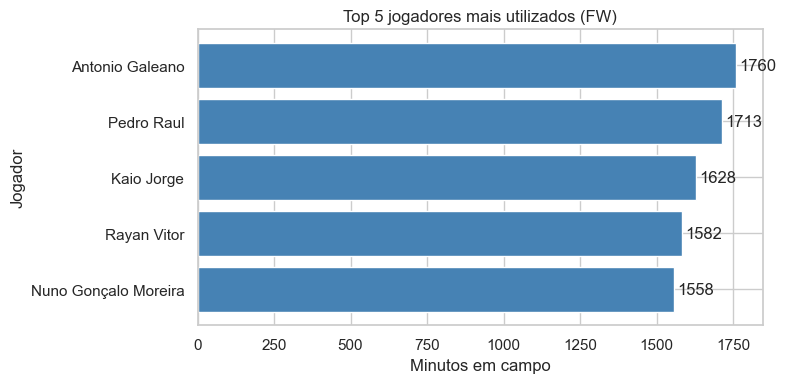

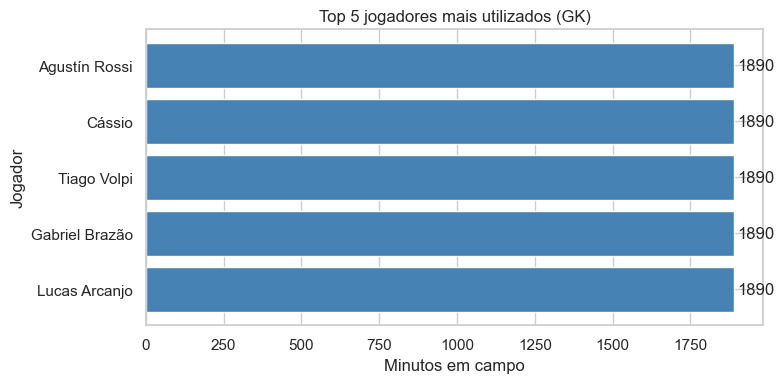

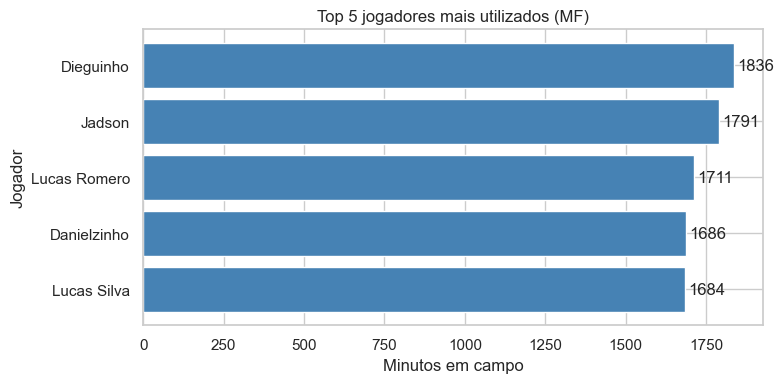

In [150]:
import matplotlib.pyplot as plt

def plot_top5_por_pos(df, n=5, min_minutos=0):
    d = df.copy()
    d["MP"]  = pd.to_numeric(d["MP"], errors="coerce")
    d["Min"] = pd.to_numeric(d["Min"], errors="coerce")
    d["Pos_simple"] = (
        d["Pos"].astype(str)
                .str.split(",|/|;")
                .str[0]
                .str.strip()
    )
    if min_minutos > 0:
        d = d[d["Min"] >= min_minutos]

    # Ordenar por posição e minutos
    d = d.sort_values(["Pos_simple","Min"], ascending=[True,False])

    # Top N por posição
    top5 = d.groupby("Pos_simple").head(n)

    # Plotar cada posição separada
    posicoes = top5["Pos_simple"].unique()
    for pos in posicoes:
        bloco = top5[top5["Pos_simple"] == pos].sort_values("Min", ascending=True)

        plt.figure(figsize=(8,4))
        plt.barh(bloco["Player"], bloco["Min"], color="steelblue")
        plt.title(f"Top {n} jogadores mais utilizados ({pos})")
        plt.xlabel("Minutos em campo")
        plt.ylabel("Jogador")

        # rótulos nos valores
        for i, v in enumerate(bloco["Min"]):
            plt.text(v + 10, i, str(int(v)), va="center")

        plt.tight_layout()
        plt.show()

# Executar
plot_top5_por_pos(serie_a, n=5, min_minutos=900)
